<a href="https://colab.research.google.com/github/santiagonajera/PlanificacionProduccion/blob/main/Clase_18_Octubre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install prophet

# Task
Genera el pronóstico de ventas para los próximos 12 meses para cada producto en el archivo Excel ubicado en "https://github.com/santiagonajera/PlanificacionProduccion/raw/refs/heads/main/Ventas_Productos_2021_2026.xlsx", utilizando la librería Prophet y considerando la estructura de datos en la pestaña 'Ventas_Unidades'.

## Cargar los datos

### Subtask:
Cargar los datos del archivo Excel desde la URL proporcionada en un DataFrame de pandas.


**Reasoning**:
Import pandas, define the URL, and load the specified sheet from the Excel file into a DataFrame.



In [2]:
import pandas as pd

excel_url = "https://github.com/santiagonajera/PlanificacionProduccion/raw/refs/heads/main/Ventas_Productos_2021_2026.xlsx"
df = pd.read_excel(excel_url, sheet_name='Ventas_Unidades')
display(df.head())

,Unnamed: 0,Producto_01,Producto_02,Producto_03,Producto_04,Producto_05,Producto_06,Producto_07,Producto_08,Producto_09,...,Producto_41,Producto_42,Producto_43,Producto_44,Producto_45,Producto_46,Producto_47,Producto_48,Producto_49,Producto_50
0,2021-01-01,1398,236,1716,896,1068,942,1535,966,330,...,1549,2002,578,276,359,673,514,1329,1309,1498
1,2021-02-01,1377,235,2387,1126,1177,1032,1566,1074,485,...,1617,2027,633,291,459,774,590,1533,1284,1958
2,2021-03-01,1405,271,2268,1175,1303,1089,1604,1075,377,...,2063,2387,804,343,348,931,623,1479,1410,1921
3,2021-04-01,2063,353,2008,1237,1083,1146,1835,1150,614,...,2267,2234,834,282,503,804,717,1457,1412,2367
4,2021-05-01,1747,311,2230,1193,1513,1370,1847,1167,434,...,2283,2263,829,359,539,1179,669,1759,1601,2557


## Preparar los datos

### Subtask:
Transformar los datos a un formato adecuado para Prophet, donde cada fila represente una fecha y una columna contenga los valores de ventas para un producto específico. Esto implicará derretir (melt) el DataFrame y renombrar las columnas a 'ds' (fecha) y 'y' (valor).


**Reasoning**:
Transform the DataFrame to a long format suitable for Prophet by melting and renaming columns.



In [3]:
df_melted = df.melt(id_vars='Unnamed: 0', var_name='Producto', value_name='Ventas')
df_melted = df_melted.rename(columns={'Unnamed: 0': 'ds', 'Ventas': 'y'})
display(df_melted.head())

,ds,Producto,y
0,2021-01-01,Producto_01,1398
1,2021-02-01,Producto_01,1377
2,2021-03-01,Producto_01,1405
3,2021-04-01,Producto_01,2063
4,2021-05-01,Producto_01,1747


## Iterar sobre cada producto

### Subtask:
Para cada producto, entrenar un modelo Prophet y generar el pronóstico para los próximos 12 meses.


**Reasoning**:
Import the Prophet class, get the unique list of products, initialize a dictionary for forecasts, and loop through each product to filter data, instantiate and fit a Prophet model, create a future dataframe for 12 months, generate the forecast, and store it in the dictionary.



In [4]:
from prophet import Prophet

unique_products = df_melted['Producto'].unique()
forecasts = {}

for product in unique_products:
    product_df = df_melted[df_melted['Producto'] == product].copy()
    model = Prophet()
    model.fit(product_df)
    future = model.make_future_dataframe(periods=12, freq='MS')
    forecast = model.predict(future)
    forecasts[product] = forecast

print("Forecasts generated for all products.")

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/w525fms7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/vobdpen2.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=61082', 'data', 'file=/tmp/tmp3_yu5at0/w525fms7.json', 'init=/tmp/tmp3_yu5at0/vobdpen2.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelgyr5oze6/prophet_model-20251018151703.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:17:03 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:17:03 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling weekly seasonali

Forecasts generated for all products.


## Visualizar los resultados

### Subtask:
Mostrar los pronósticos para cada producto.


**Reasoning**:
Iterate through the forecasts dictionary and plot the forecast for each product using the Prophet model's plot method, adding a title to each plot.



TypeError: 'NoneType' object is not subscriptable

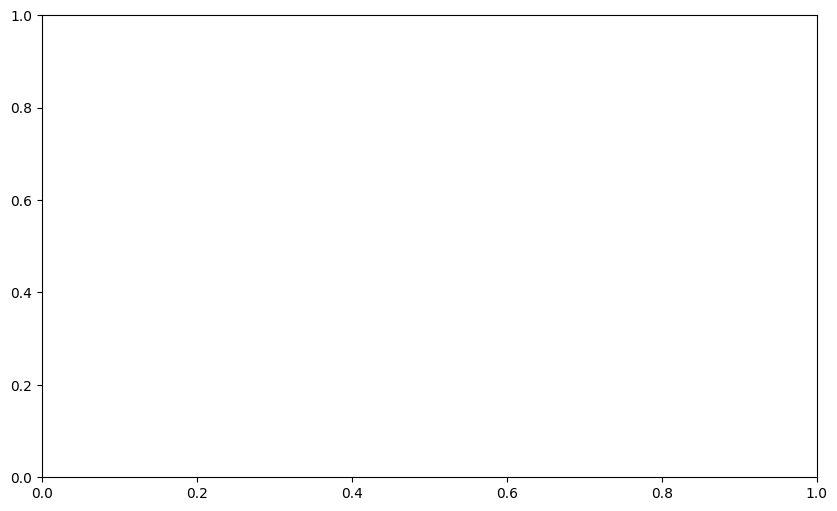

In [5]:
import matplotlib.pyplot as plt

for product, forecast in forecasts.items():
    model = Prophet()
    fig = model.plot(forecast)
    ax = fig.gca()
    ax.set_title(f'Forecast for {product}')
    plt.show()

**Reasoning**:
The error indicates that the Prophet model object is not properly initialized or fitted before attempting to plot. The model needs to be fitted with data before plotting. The previous code block created a new Prophet model in each iteration but did not fit it. The model should be fitted with the historical data for each product before plotting the forecast.



INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/kvrpifub.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/5fhnrsr_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=6799', 'data', 'file=/tmp/tmp3_yu5at0/kvrpifub.json', 'init=/tmp/tmp3_yu5at0/5fhnrsr_.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_model87yffu4y/prophet_model-20251018151814.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:14 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:15 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


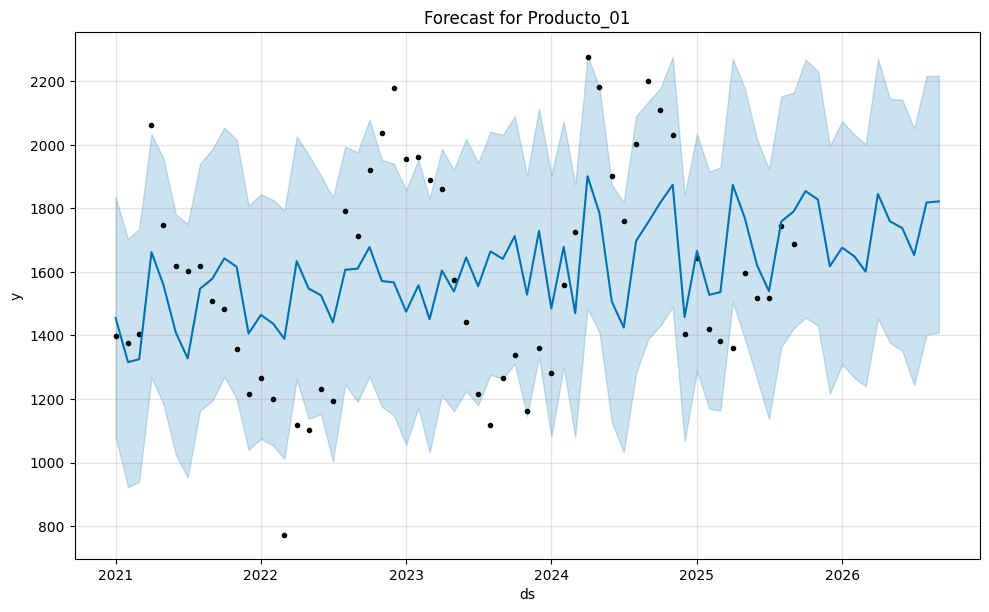

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/xte7pr7k.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/p02vbl4q.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=27273', 'data', 'file=/tmp/tmp3_yu5at0/xte7pr7k.json', 'init=/tmp/tmp3_yu5at0/p02vbl4q.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelmdwg9b9t/prophet_model-20251018151816.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:16 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:17 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


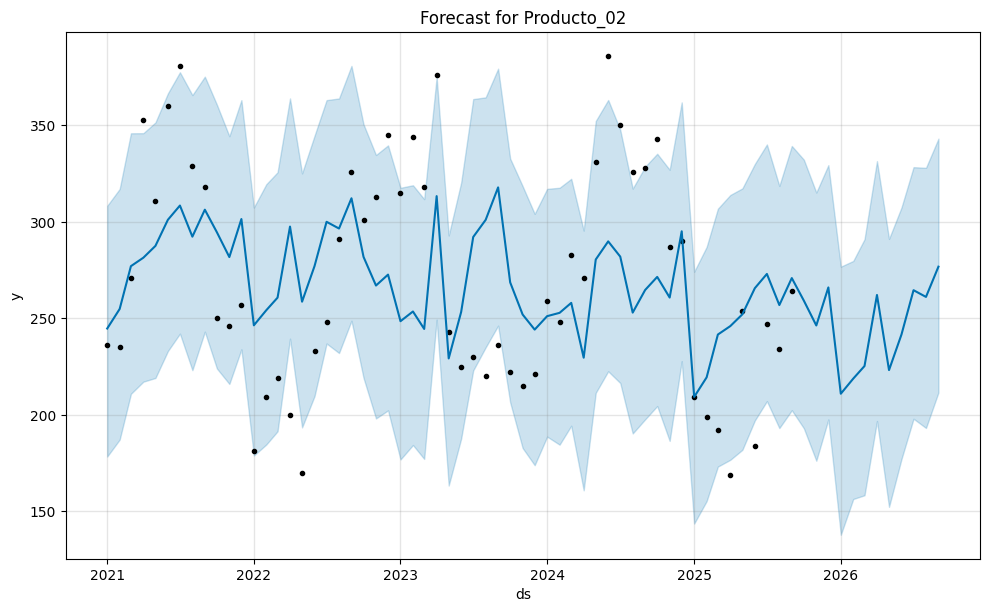

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/8h53_y1j.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/qh8fj6ii.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=24456', 'data', 'file=/tmp/tmp3_yu5at0/8h53_y1j.json', 'init=/tmp/tmp3_yu5at0/qh8fj6ii.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_model3wax79am/prophet_model-20251018151817.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:17 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:17 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


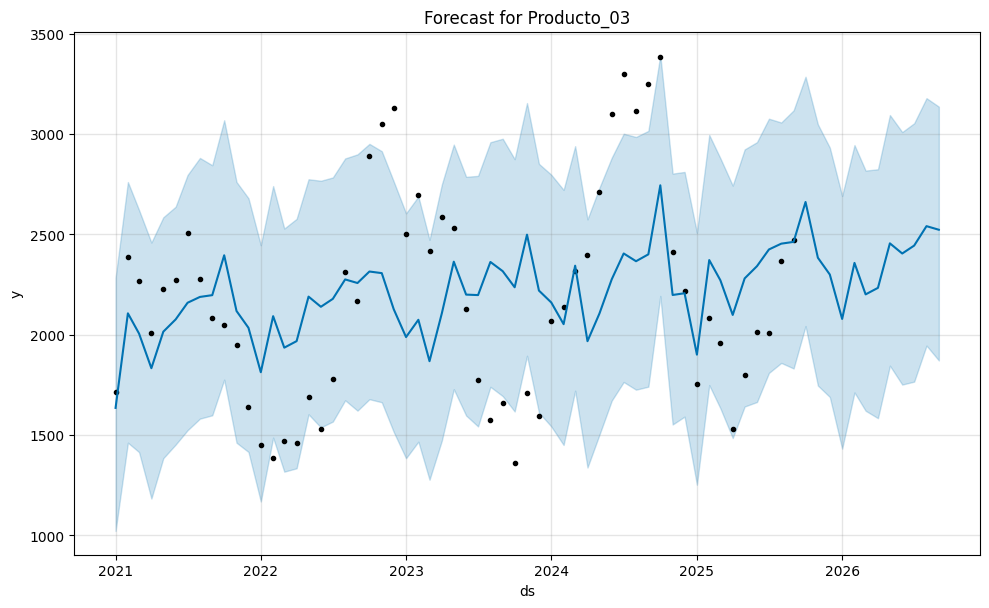

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/s4mhua_b.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/muf2z6lk.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=88189', 'data', 'file=/tmp/tmp3_yu5at0/s4mhua_b.json', 'init=/tmp/tmp3_yu5at0/muf2z6lk.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_model_j7trt_o/prophet_model-20251018151818.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:18 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


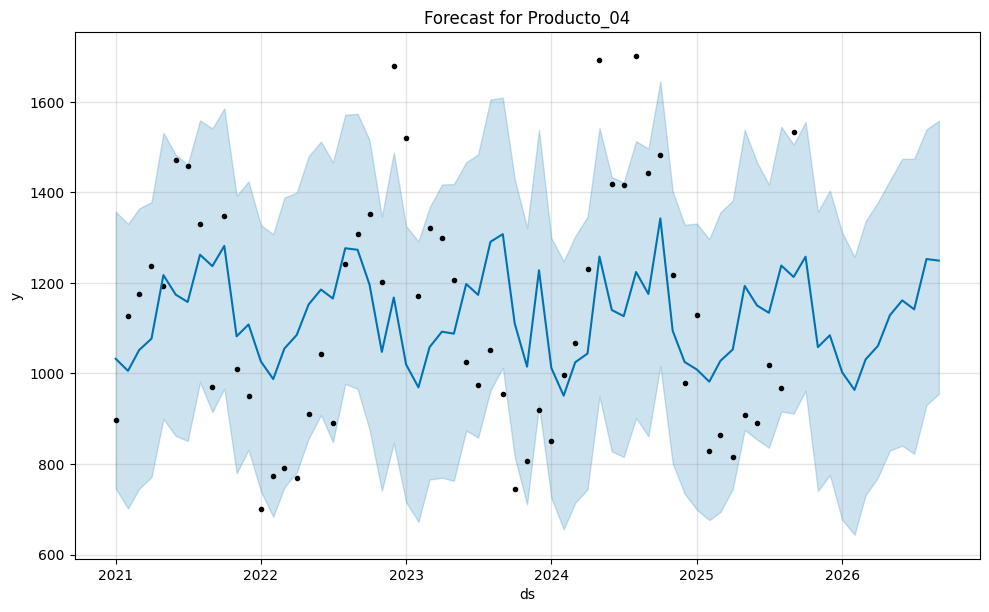

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/g3aqmje7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/8h7m022v.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=84716', 'data', 'file=/tmp/tmp3_yu5at0/g3aqmje7.json', 'init=/tmp/tmp3_yu5at0/8h7m022v.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_model32wprqzz/prophet_model-20251018151819.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:19 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:19 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


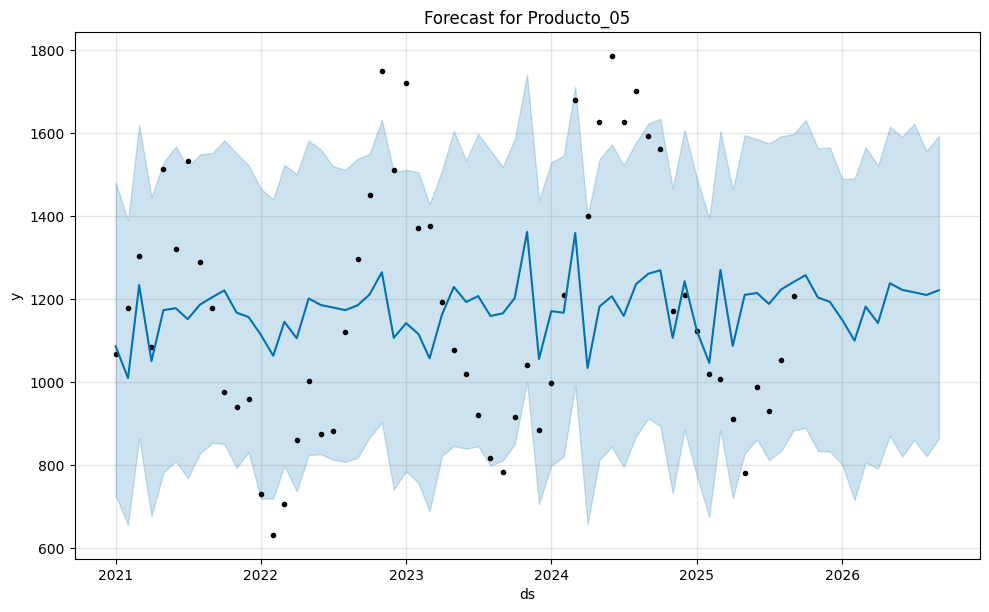

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/svrotgez.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/fat16au3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=58253', 'data', 'file=/tmp/tmp3_yu5at0/svrotgez.json', 'init=/tmp/tmp3_yu5at0/fat16au3.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_model7ry3nkwu/prophet_model-20251018151819.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:19 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:19 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


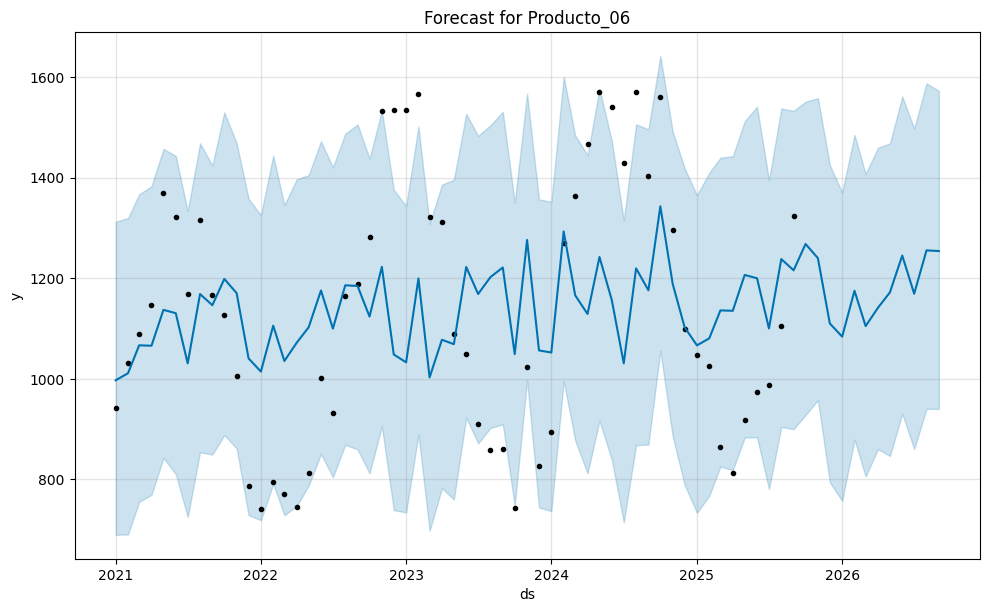

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/2o07tw_a.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/ev1_6ygd.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=22306', 'data', 'file=/tmp/tmp3_yu5at0/2o07tw_a.json', 'init=/tmp/tmp3_yu5at0/ev1_6ygd.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_model5dx6fcyc/prophet_model-20251018151820.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


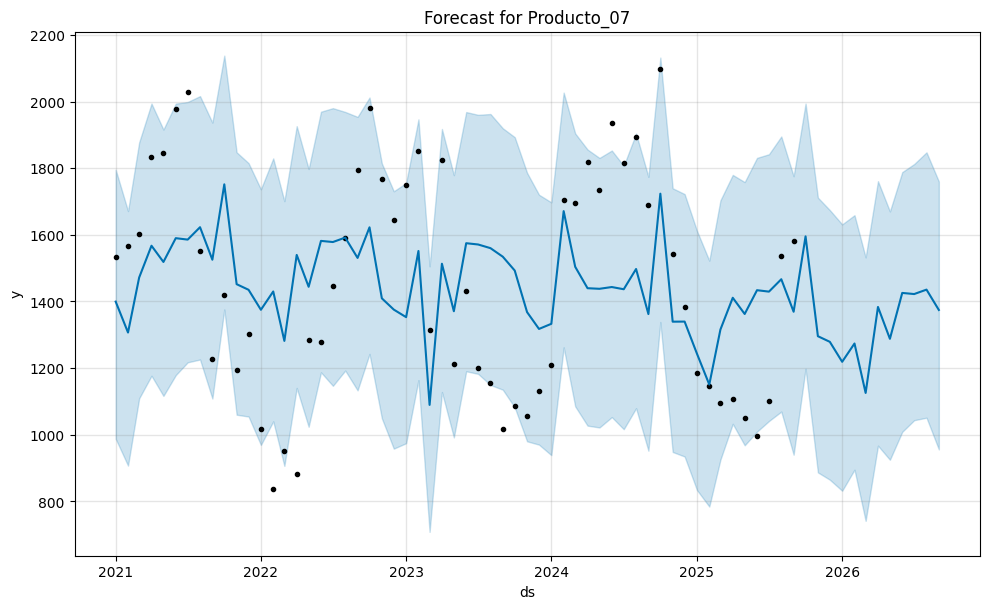

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/kiciaeuh.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/vqvfly0g.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=83406', 'data', 'file=/tmp/tmp3_yu5at0/kiciaeuh.json', 'init=/tmp/tmp3_yu5at0/vqvfly0g.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_model3emmjmmn/prophet_model-20251018151820.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:21 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


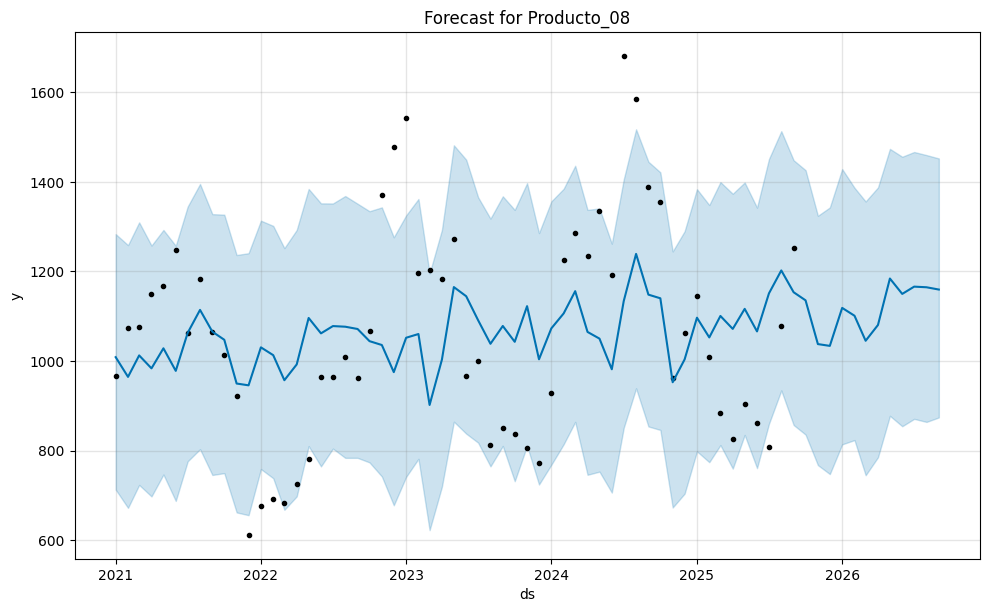

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/aji3ahhw.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/sxallxgc.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=20173', 'data', 'file=/tmp/tmp3_yu5at0/aji3ahhw.json', 'init=/tmp/tmp3_yu5at0/sxallxgc.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelqyljj17c/prophet_model-20251018151821.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:21 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:21 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


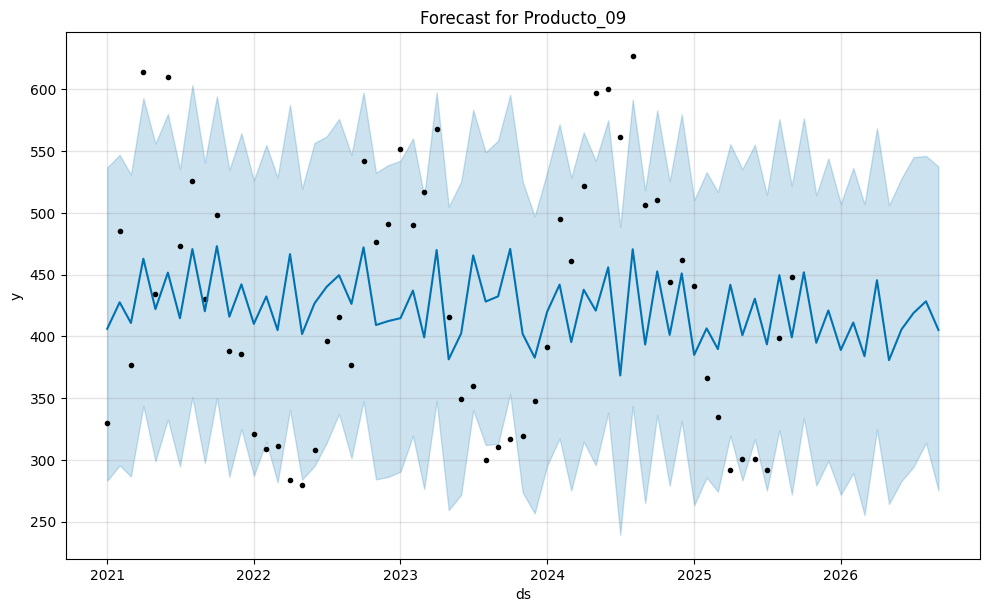

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/q8we_z8q.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/_k8aj4x8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=10957', 'data', 'file=/tmp/tmp3_yu5at0/q8we_z8q.json', 'init=/tmp/tmp3_yu5at0/_k8aj4x8.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelmrd4tqxd/prophet_model-20251018151822.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:22 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:22 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


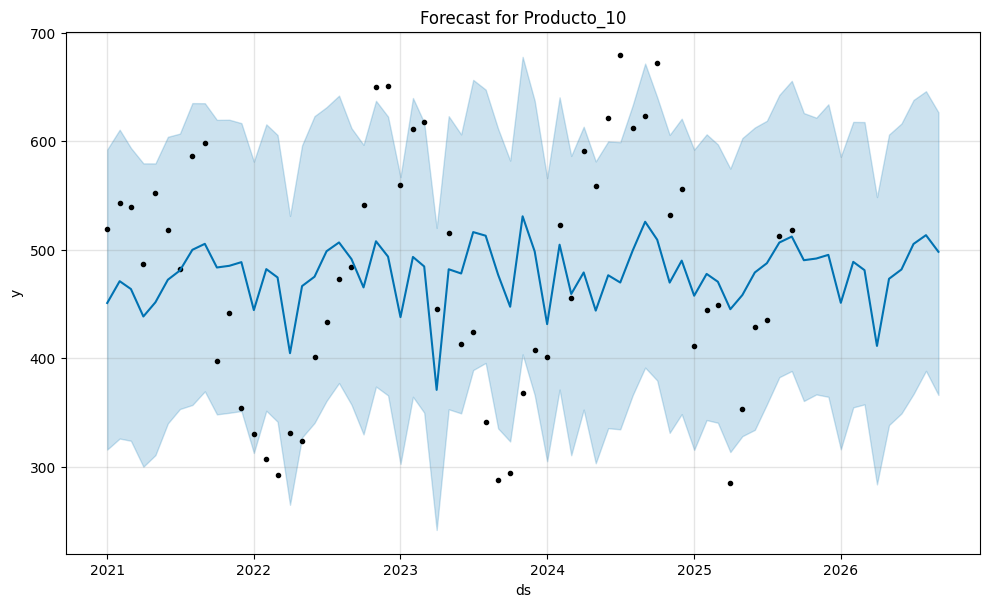

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/zckb83c4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/pcpzwq22.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=30023', 'data', 'file=/tmp/tmp3_yu5at0/zckb83c4.json', 'init=/tmp/tmp3_yu5at0/pcpzwq22.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelsuboaae1/prophet_model-20251018151822.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:22 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:23 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


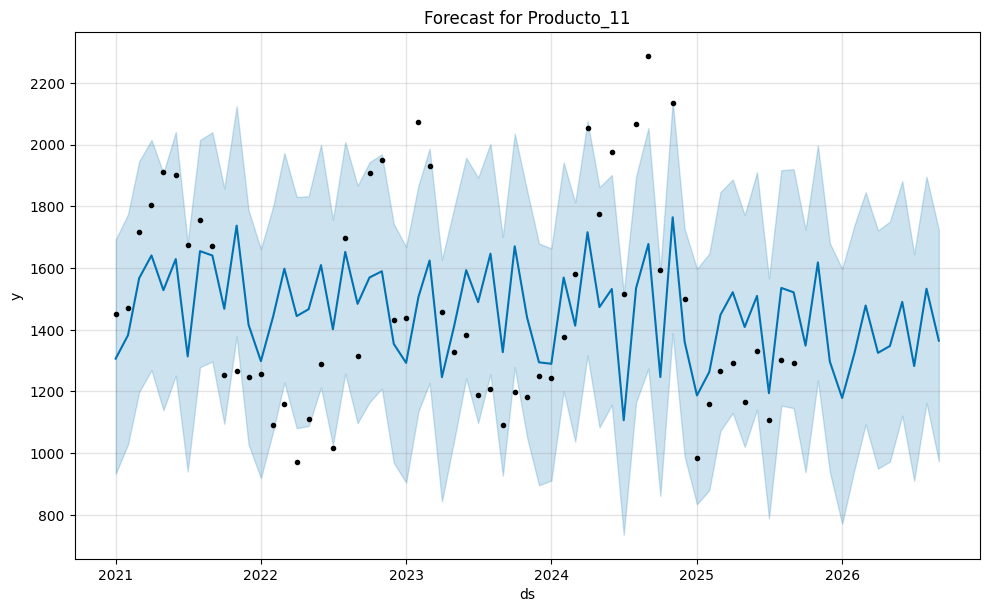

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/lmbk949e.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/4ehpfr7z.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=87787', 'data', 'file=/tmp/tmp3_yu5at0/lmbk949e.json', 'init=/tmp/tmp3_yu5at0/4ehpfr7z.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelx1ultzfo/prophet_model-20251018151823.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:23 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:23 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


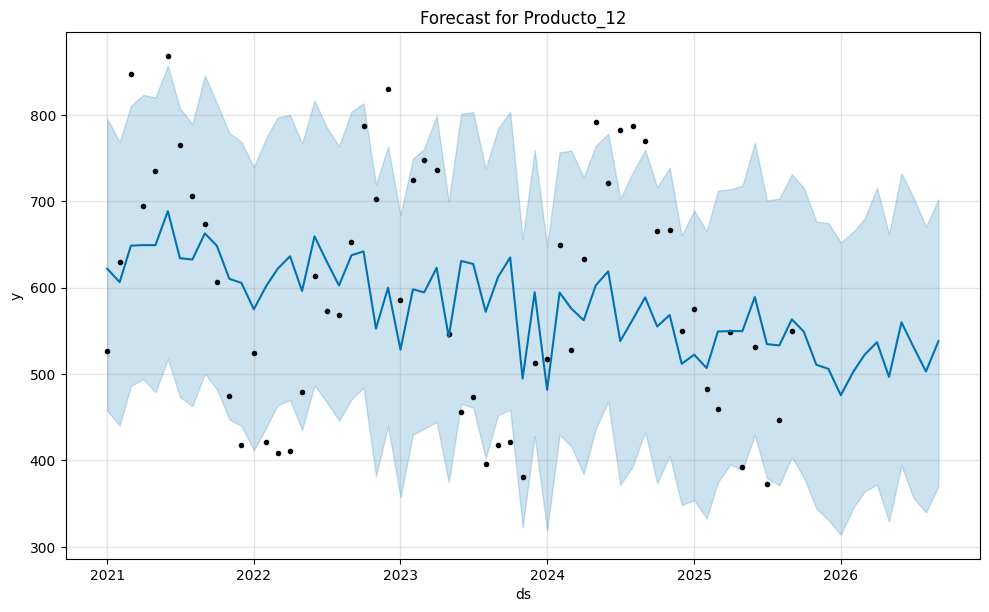

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/5c260k14.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/bm7uvwjk.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=54683', 'data', 'file=/tmp/tmp3_yu5at0/5c260k14.json', 'init=/tmp/tmp3_yu5at0/bm7uvwjk.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelxjktciud/prophet_model-20251018151824.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:24 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:24 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


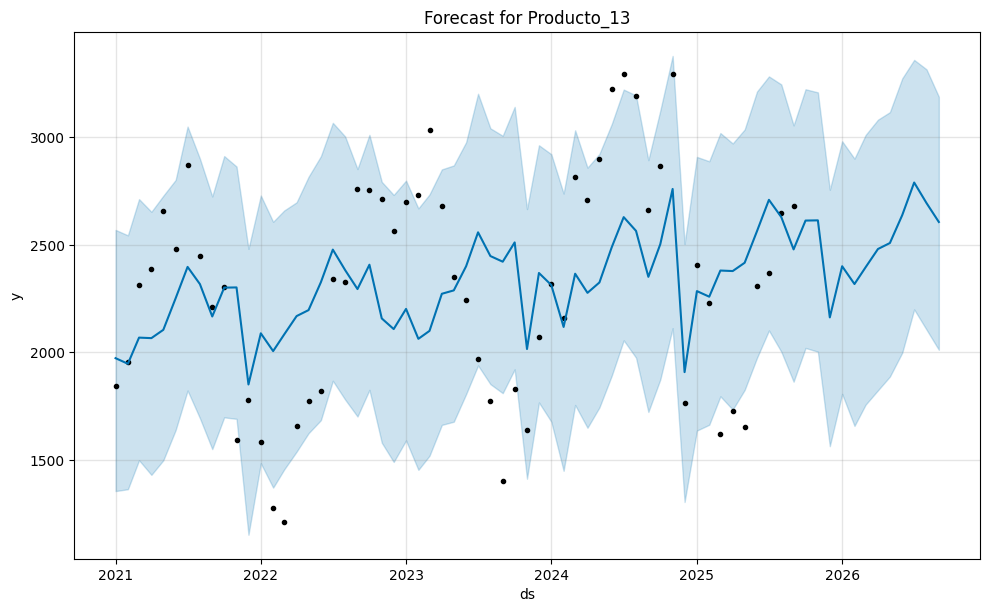

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/gi_2nzn7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/9i0ih06c.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=87714', 'data', 'file=/tmp/tmp3_yu5at0/gi_2nzn7.json', 'init=/tmp/tmp3_yu5at0/9i0ih06c.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelnbm7lxw3/prophet_model-20251018151825.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:25 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:25 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


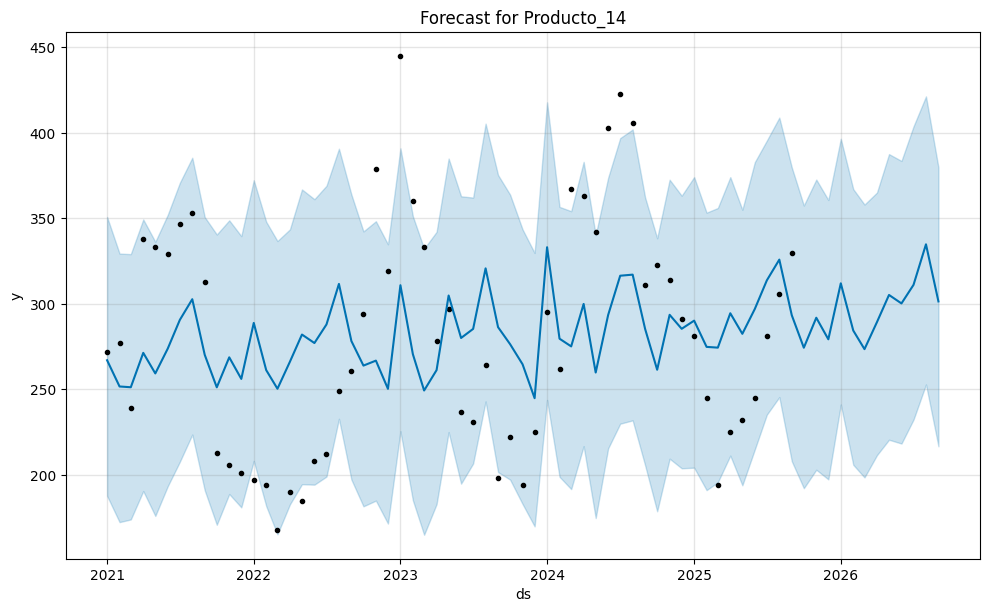

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/i49w_0n0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/26g56r7x.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=65999', 'data', 'file=/tmp/tmp3_yu5at0/i49w_0n0.json', 'init=/tmp/tmp3_yu5at0/26g56r7x.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modellzi0h4f9/prophet_model-20251018151825.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:25 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:26 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


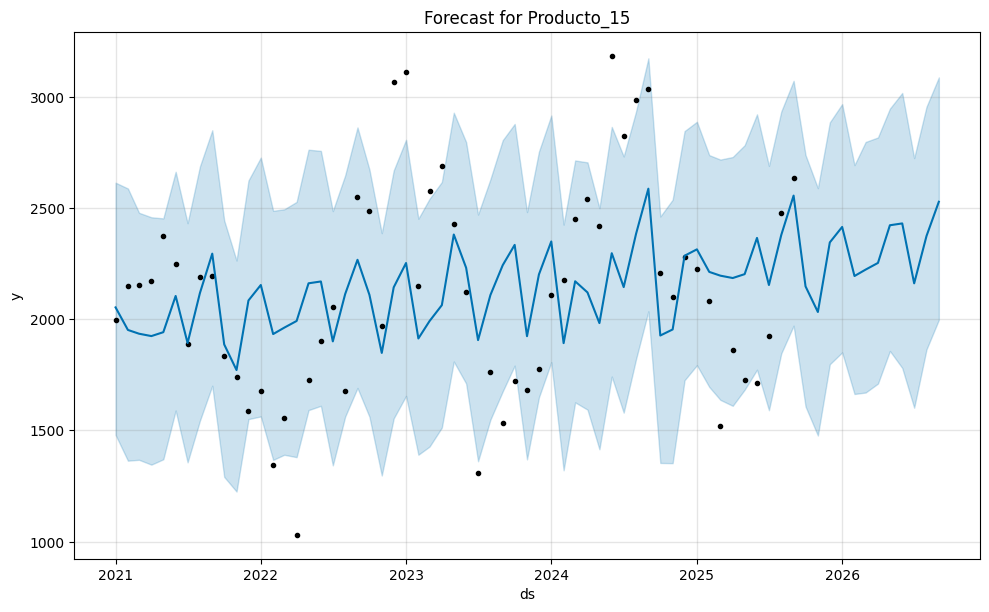

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/jlfyccr_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/ip8i4_id.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=97207', 'data', 'file=/tmp/tmp3_yu5at0/jlfyccr_.json', 'init=/tmp/tmp3_yu5at0/ip8i4_id.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelxm8m3uaa/prophet_model-20251018151826.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:26 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


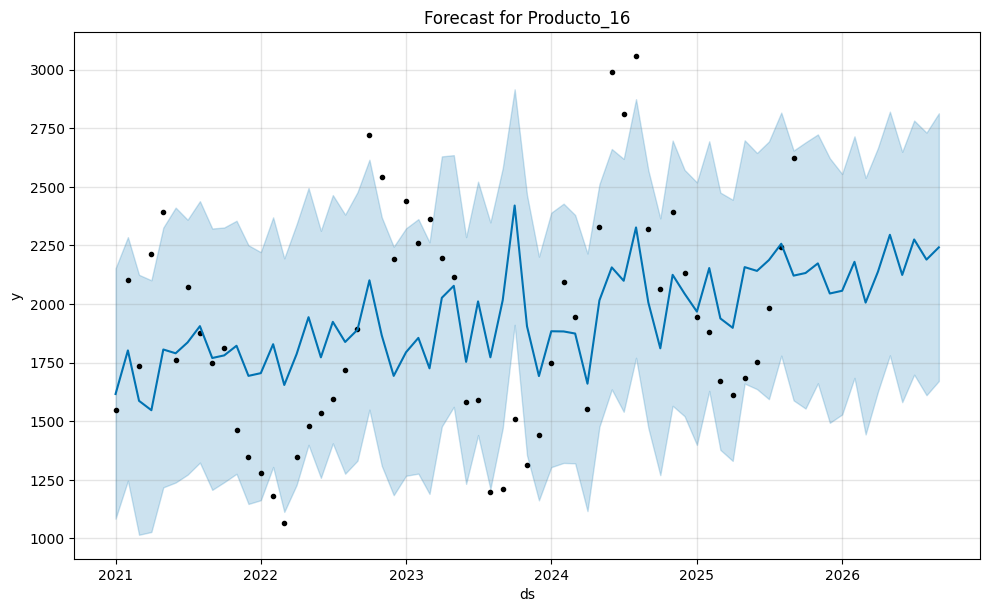

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/zal1dz8y.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/q4_n8dcj.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=51869', 'data', 'file=/tmp/tmp3_yu5at0/zal1dz8y.json', 'init=/tmp/tmp3_yu5at0/q4_n8dcj.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelwnq17hkv/prophet_model-20251018151827.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:27 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:27 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


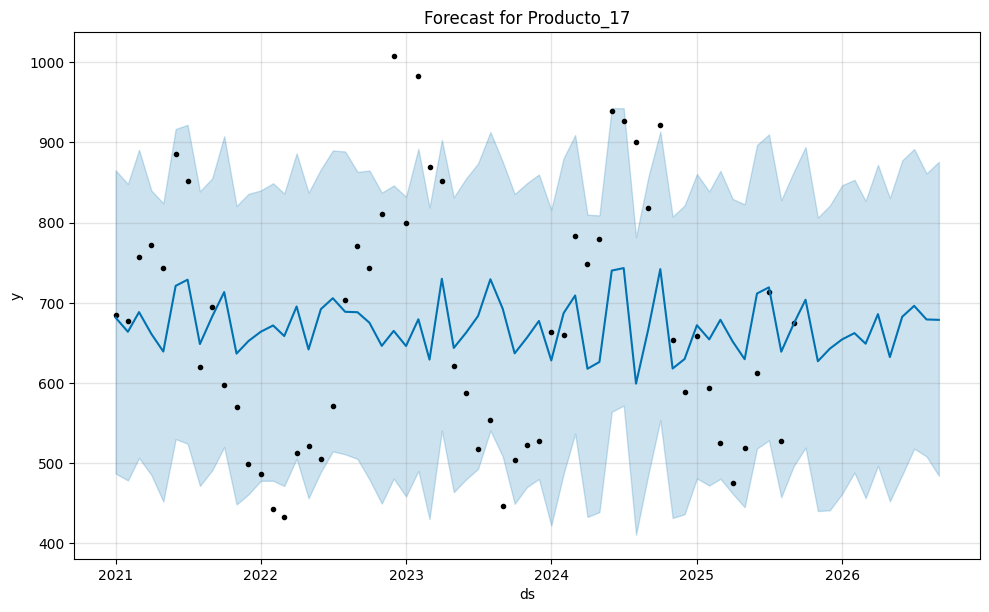

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/vxqy9d85.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/rz9u3myj.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=63236', 'data', 'file=/tmp/tmp3_yu5at0/vxqy9d85.json', 'init=/tmp/tmp3_yu5at0/rz9u3myj.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_model8f_j0354/prophet_model-20251018151828.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:28 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


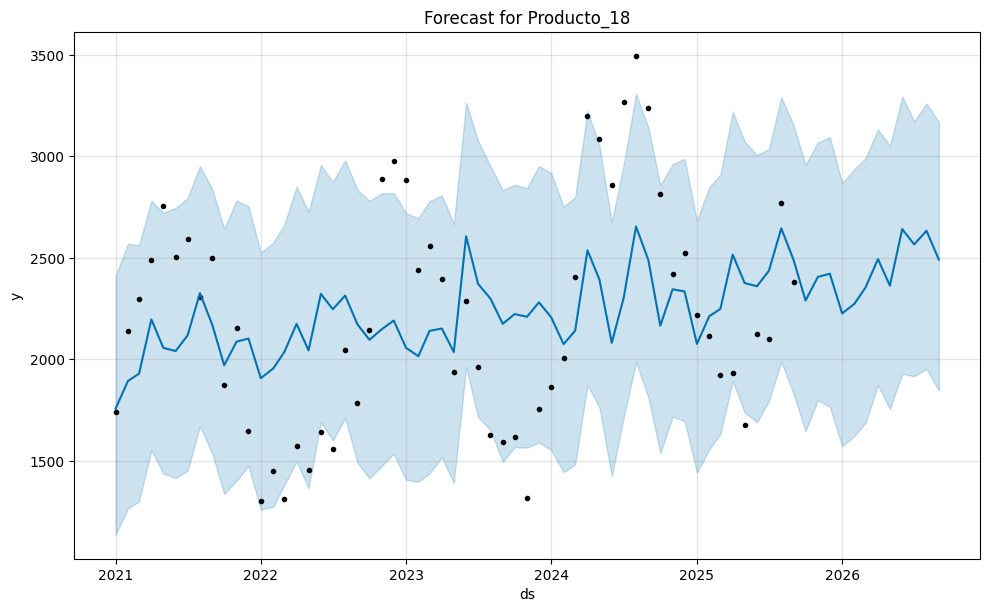

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/qn_aq4gu.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/2clcmq0d.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=11184', 'data', 'file=/tmp/tmp3_yu5at0/qn_aq4gu.json', 'init=/tmp/tmp3_yu5at0/2clcmq0d.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modeliobc9nw4/prophet_model-20251018151829.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:29 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:29 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


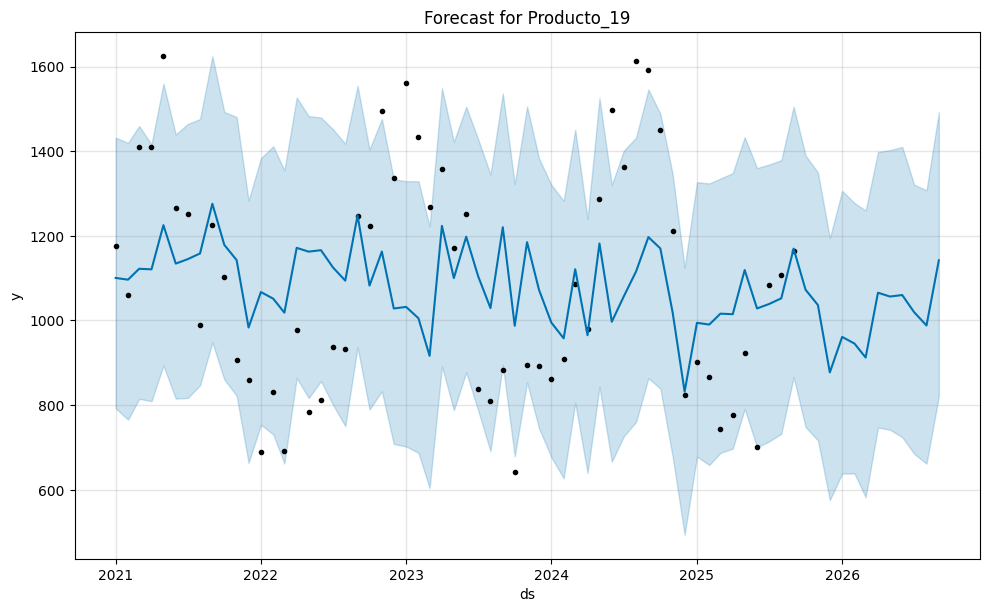

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/c2kw0kt6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/4d0qstu6.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=45096', 'data', 'file=/tmp/tmp3_yu5at0/c2kw0kt6.json', 'init=/tmp/tmp3_yu5at0/4d0qstu6.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelz7qlff21/prophet_model-20251018151830.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:30 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:30 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


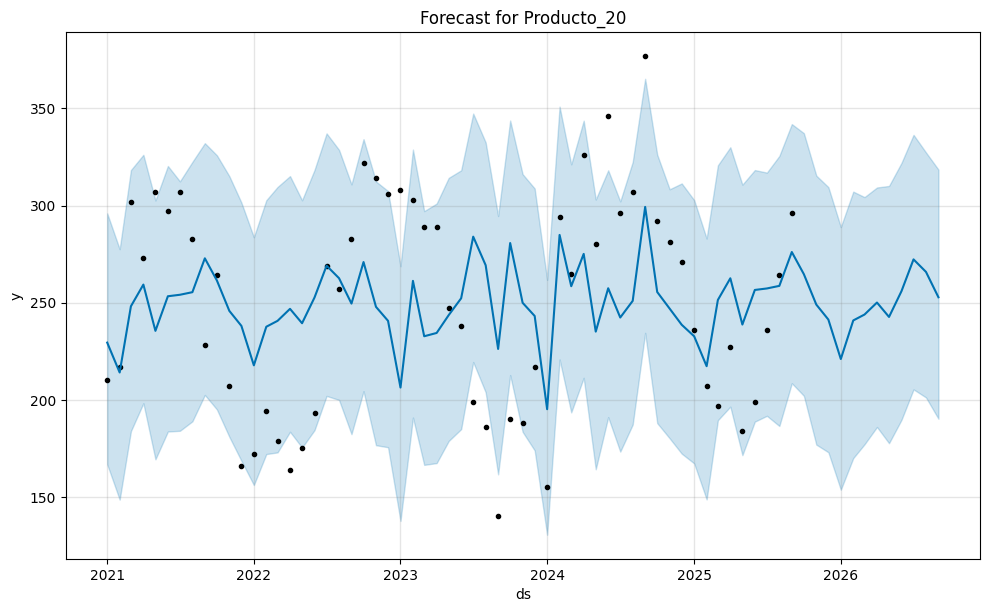

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/86kp0age.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/h2qkchts.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=7096', 'data', 'file=/tmp/tmp3_yu5at0/86kp0age.json', 'init=/tmp/tmp3_yu5at0/h2qkchts.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelh14oa87k/prophet_model-20251018151830.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:30 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:31 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


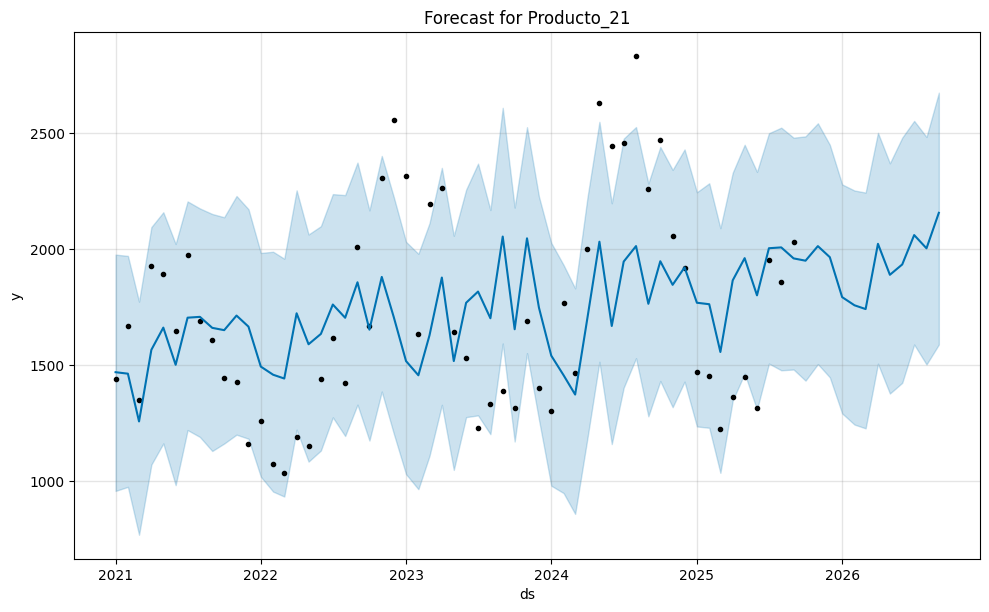

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/owen455v.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/ne0bwo4_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=6900', 'data', 'file=/tmp/tmp3_yu5at0/owen455v.json', 'init=/tmp/tmp3_yu5at0/ne0bwo4_.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelkkctb3qk/prophet_model-20251018151831.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:31 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:32 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


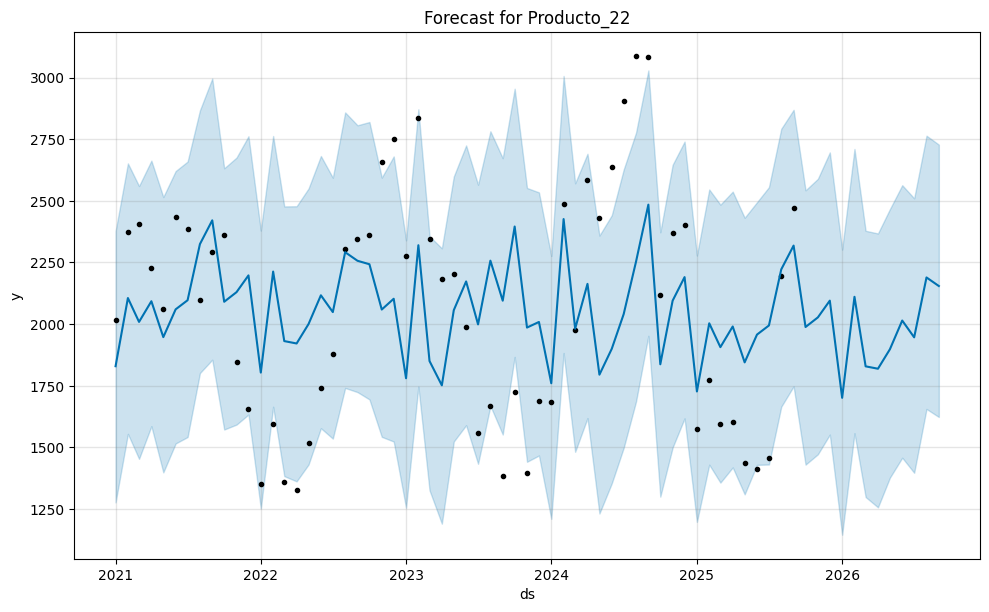

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/9s7zkzk7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/gztv1pkq.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=65720', 'data', 'file=/tmp/tmp3_yu5at0/9s7zkzk7.json', 'init=/tmp/tmp3_yu5at0/gztv1pkq.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelogcph3gm/prophet_model-20251018151832.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:32 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:33 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


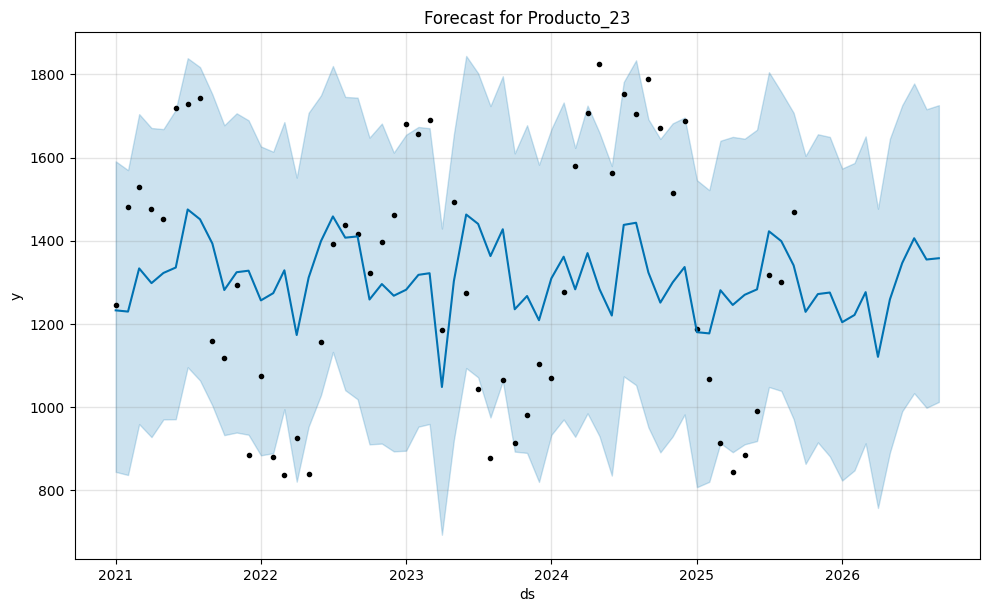

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/x4bf7kl_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/ximf4gc1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=28289', 'data', 'file=/tmp/tmp3_yu5at0/x4bf7kl_.json', 'init=/tmp/tmp3_yu5at0/ximf4gc1.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelul4fb_6g/prophet_model-20251018151833.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:33 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:33 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


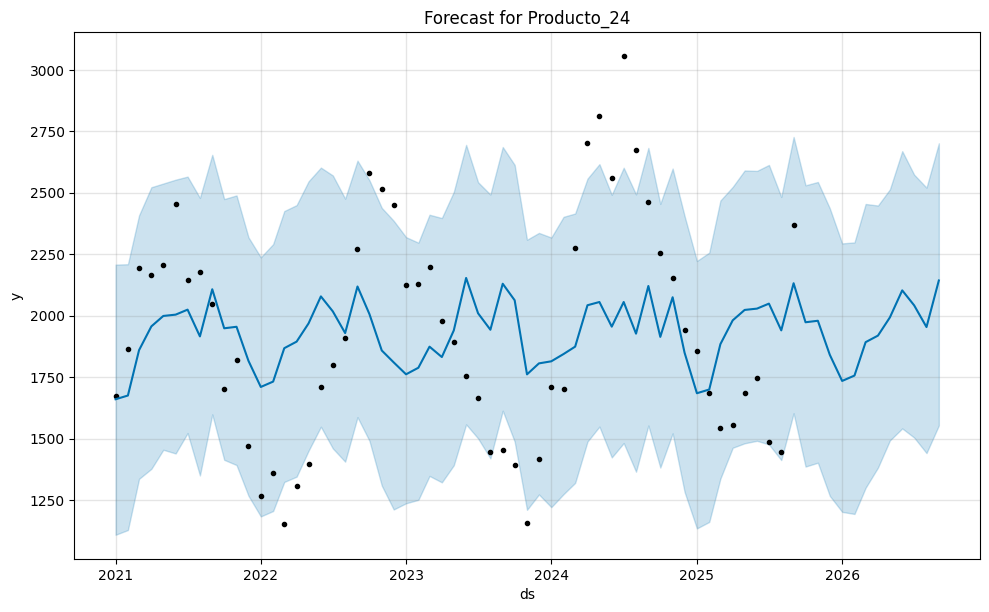

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/vaeptie2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/pj5s2i96.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=1225', 'data', 'file=/tmp/tmp3_yu5at0/vaeptie2.json', 'init=/tmp/tmp3_yu5at0/pj5s2i96.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelumofo0os/prophet_model-20251018151834.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:34 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:34 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


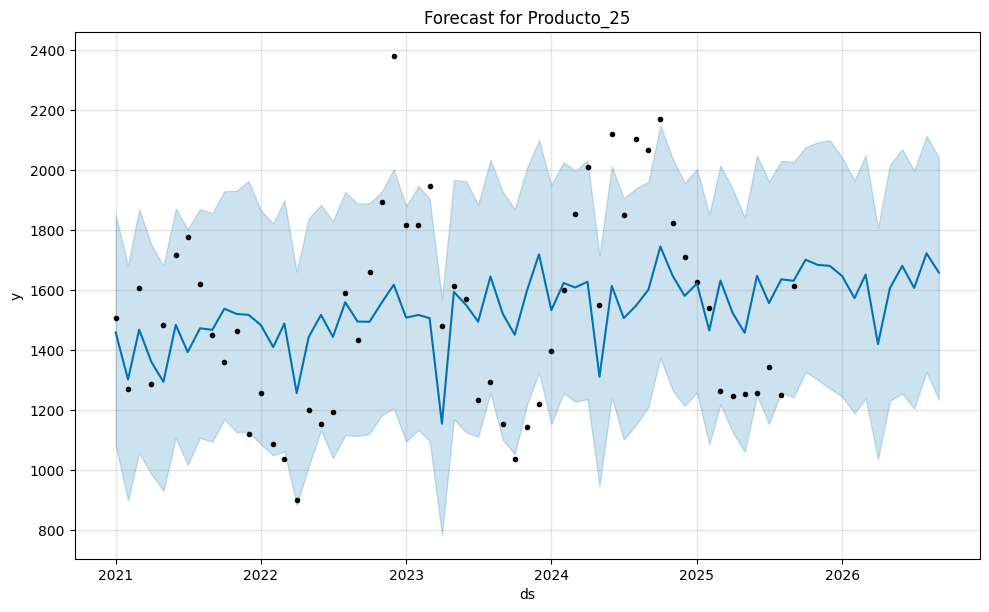

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/gdi67hwq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/zclczfa0.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=27762', 'data', 'file=/tmp/tmp3_yu5at0/gdi67hwq.json', 'init=/tmp/tmp3_yu5at0/zclczfa0.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_model4vq1laf2/prophet_model-20251018151835.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


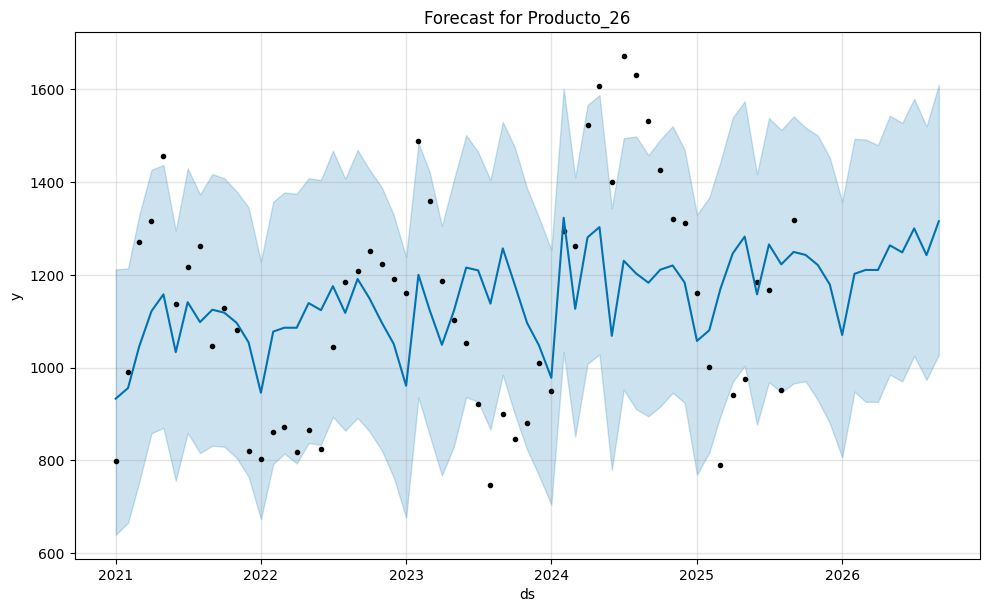

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/azbhzbmn.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/ezu2amu5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=73412', 'data', 'file=/tmp/tmp3_yu5at0/azbhzbmn.json', 'init=/tmp/tmp3_yu5at0/ezu2amu5.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_model40ww8krw/prophet_model-20251018151836.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:36 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


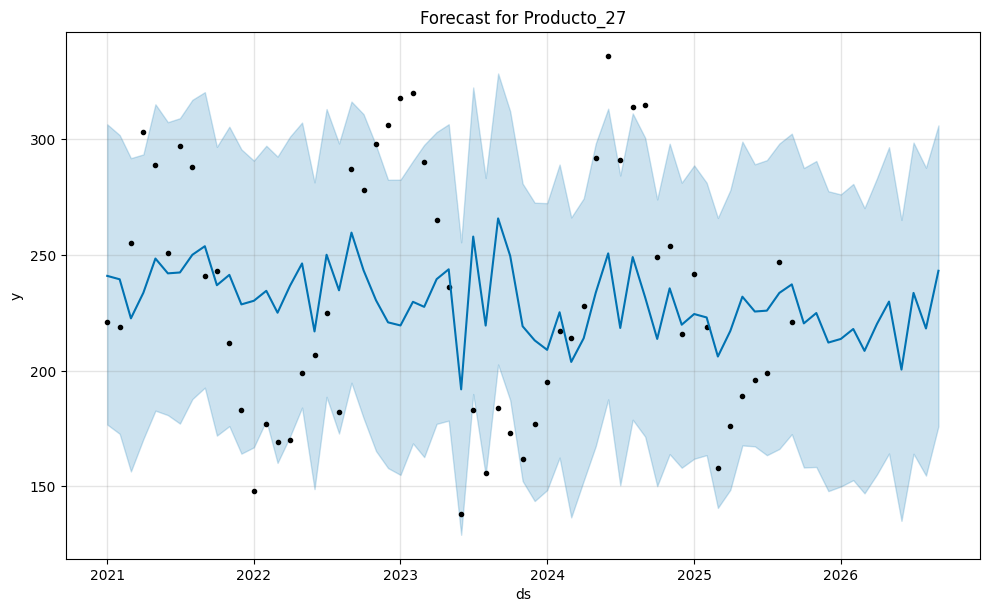

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/l0bf5xth.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/k7roz8h_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=3680', 'data', 'file=/tmp/tmp3_yu5at0/l0bf5xth.json', 'init=/tmp/tmp3_yu5at0/k7roz8h_.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelupdxt1cp/prophet_model-20251018151836.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:37 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


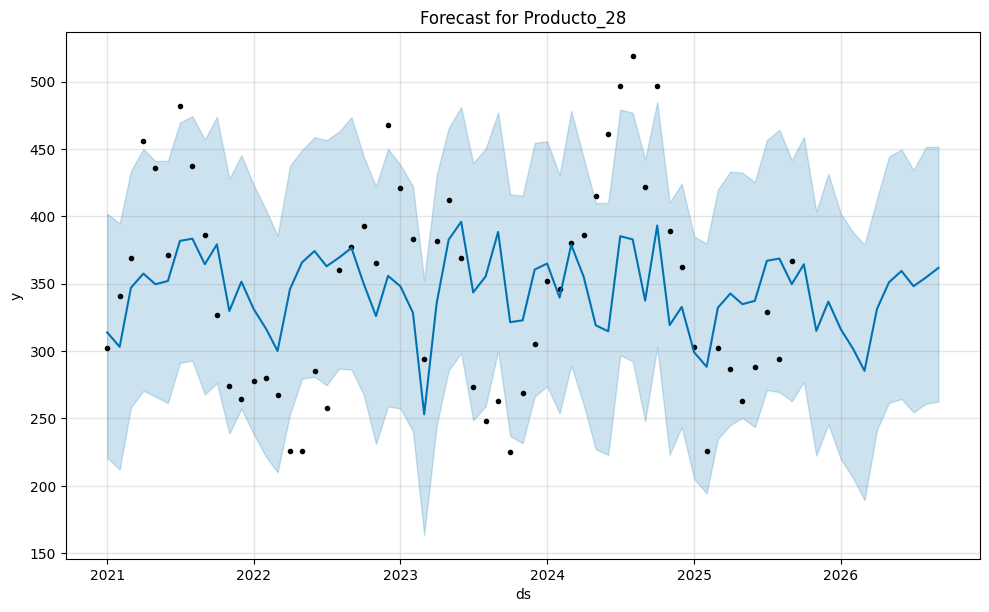

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/hv4m86ny.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/puz_v0k7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=14898', 'data', 'file=/tmp/tmp3_yu5at0/hv4m86ny.json', 'init=/tmp/tmp3_yu5at0/puz_v0k7.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_models1vy5ly1/prophet_model-20251018151837.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:37 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:38 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


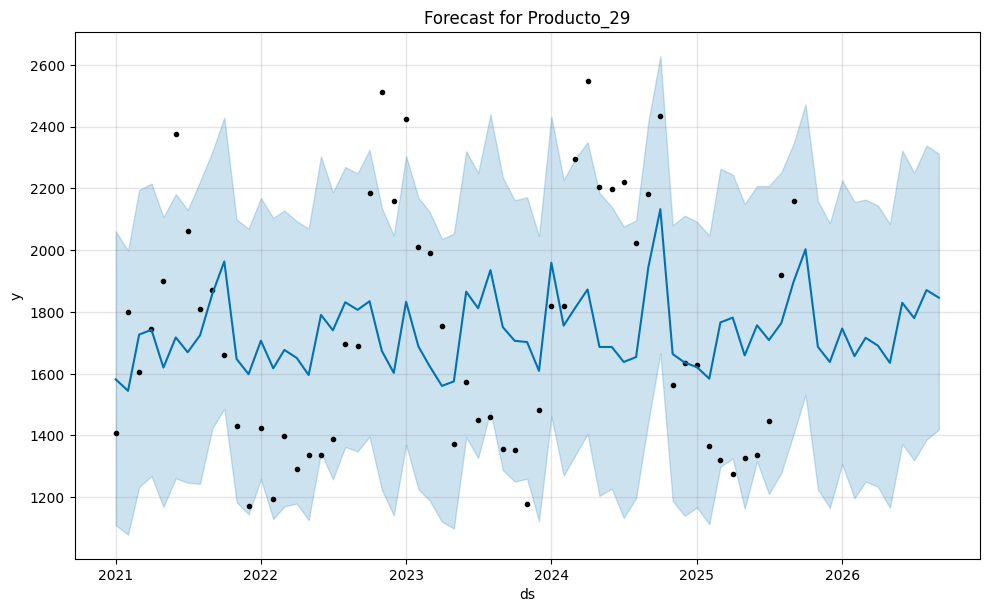

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/e4ng19vd.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/0lodxsva.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=68177', 'data', 'file=/tmp/tmp3_yu5at0/e4ng19vd.json', 'init=/tmp/tmp3_yu5at0/0lodxsva.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelxeaxxp45/prophet_model-20251018151838.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:38 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:38 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


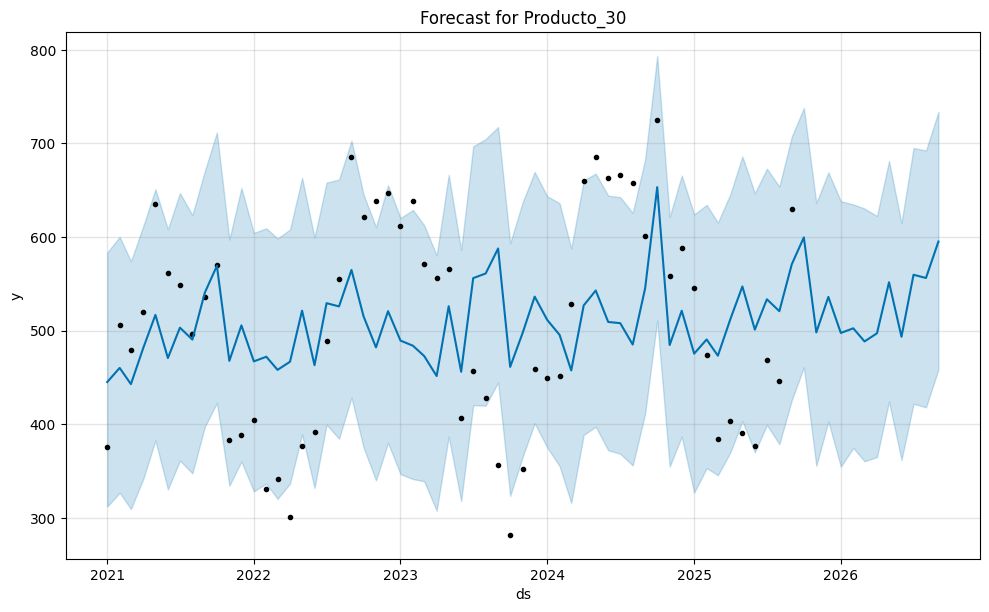

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/gnfedydn.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/bfuoafrk.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=8478', 'data', 'file=/tmp/tmp3_yu5at0/gnfedydn.json', 'init=/tmp/tmp3_yu5at0/bfuoafrk.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelwc48hzn8/prophet_model-20251018151839.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:39 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:39 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


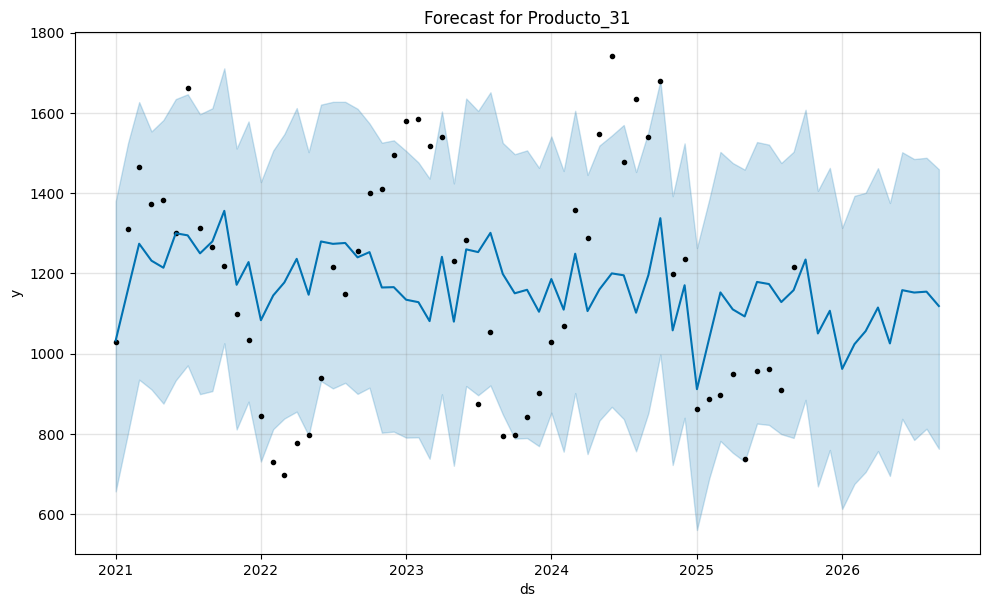

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/qeqejfz7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/vl53j9f7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=59839', 'data', 'file=/tmp/tmp3_yu5at0/qeqejfz7.json', 'init=/tmp/tmp3_yu5at0/vl53j9f7.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelorhqubdg/prophet_model-20251018151840.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:40 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:40 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


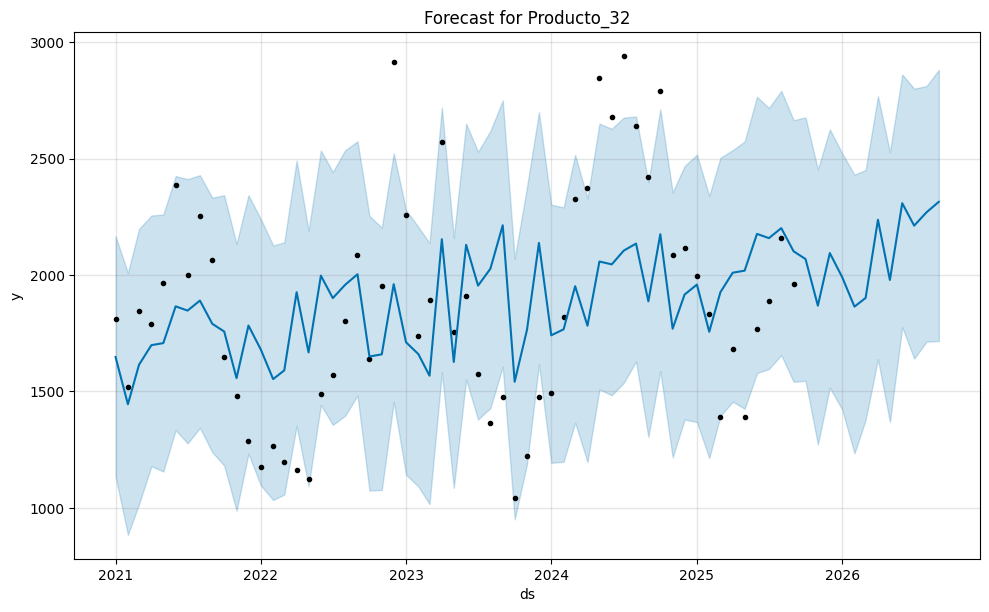

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/fc2w5cvx.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/8ndw1xkx.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=29333', 'data', 'file=/tmp/tmp3_yu5at0/fc2w5cvx.json', 'init=/tmp/tmp3_yu5at0/8ndw1xkx.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelzpaq8nfq/prophet_model-20251018151841.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:41 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:41 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


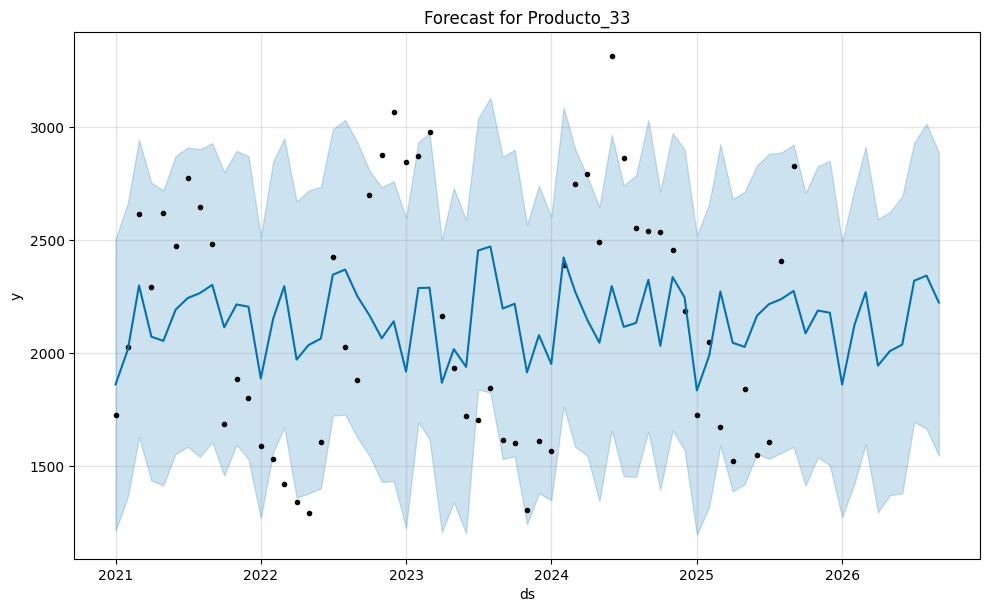

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/02gv2yg7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/nornwtyn.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=22992', 'data', 'file=/tmp/tmp3_yu5at0/02gv2yg7.json', 'init=/tmp/tmp3_yu5at0/nornwtyn.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modeljb834bsa/prophet_model-20251018151842.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:42 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:42 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


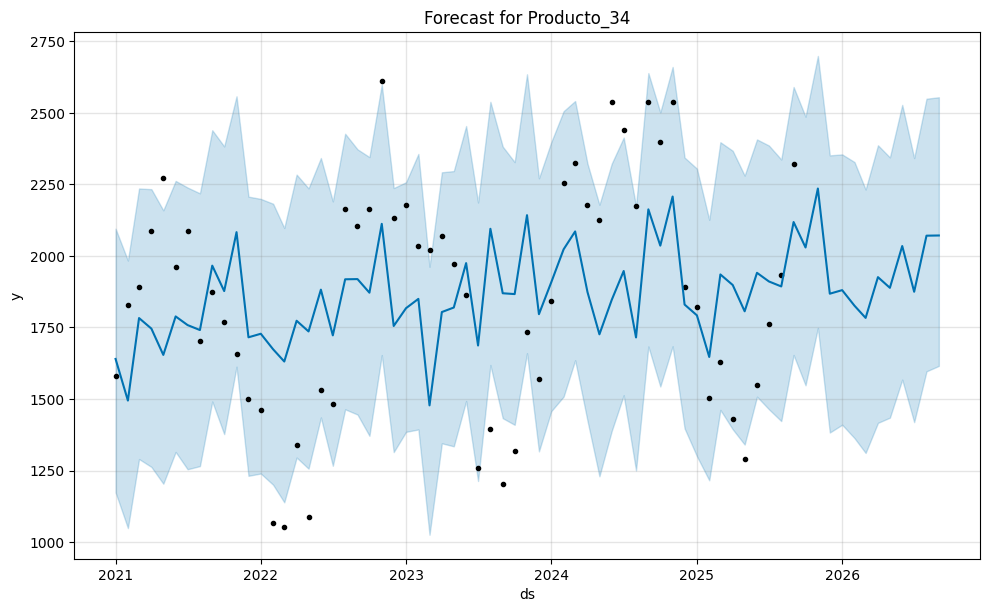

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/jj09gpa3.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/47w3ewxg.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=72808', 'data', 'file=/tmp/tmp3_yu5at0/jj09gpa3.json', 'init=/tmp/tmp3_yu5at0/47w3ewxg.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelfxtpkc0l/prophet_model-20251018151843.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:43 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:43 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


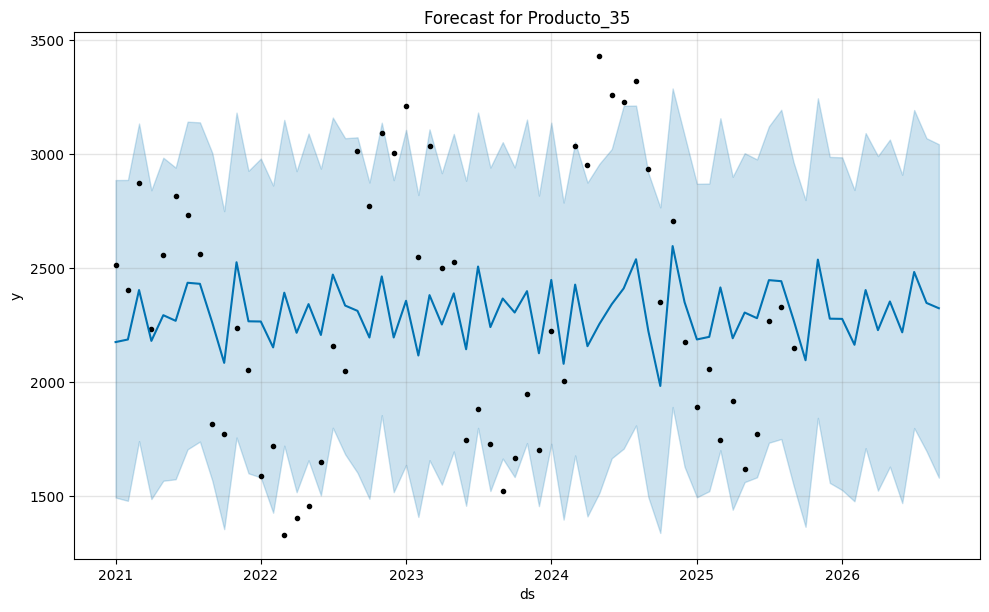

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/ge3mur4y.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/16ma3636.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=73756', 'data', 'file=/tmp/tmp3_yu5at0/ge3mur4y.json', 'init=/tmp/tmp3_yu5at0/16ma3636.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modeljor1sycr/prophet_model-20251018151843.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:43 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:44 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


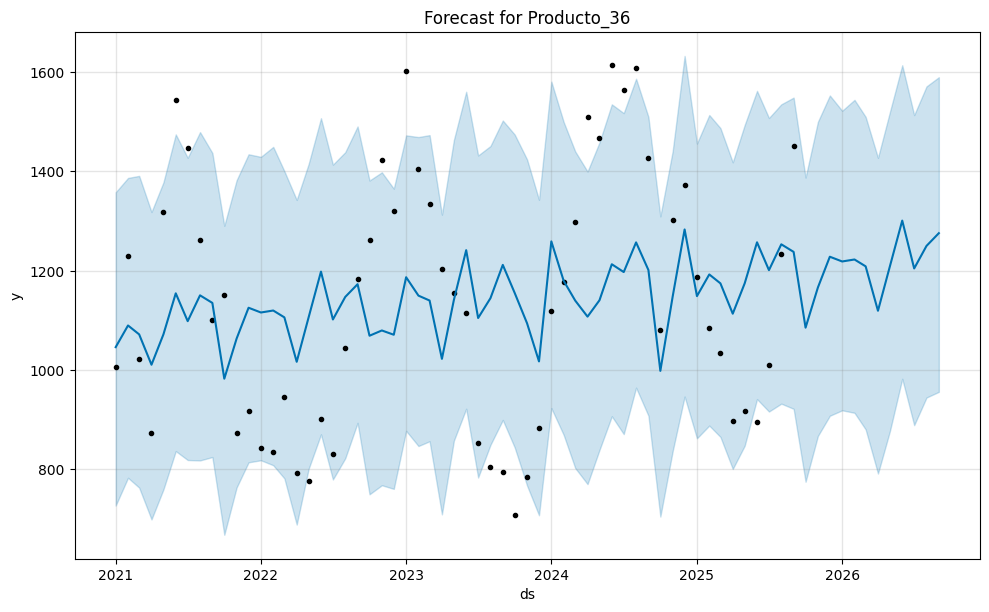

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/bt3ho2y2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/ag8llawu.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=73345', 'data', 'file=/tmp/tmp3_yu5at0/bt3ho2y2.json', 'init=/tmp/tmp3_yu5at0/ag8llawu.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_model5evpxgph/prophet_model-20251018151844.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:44 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:45 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


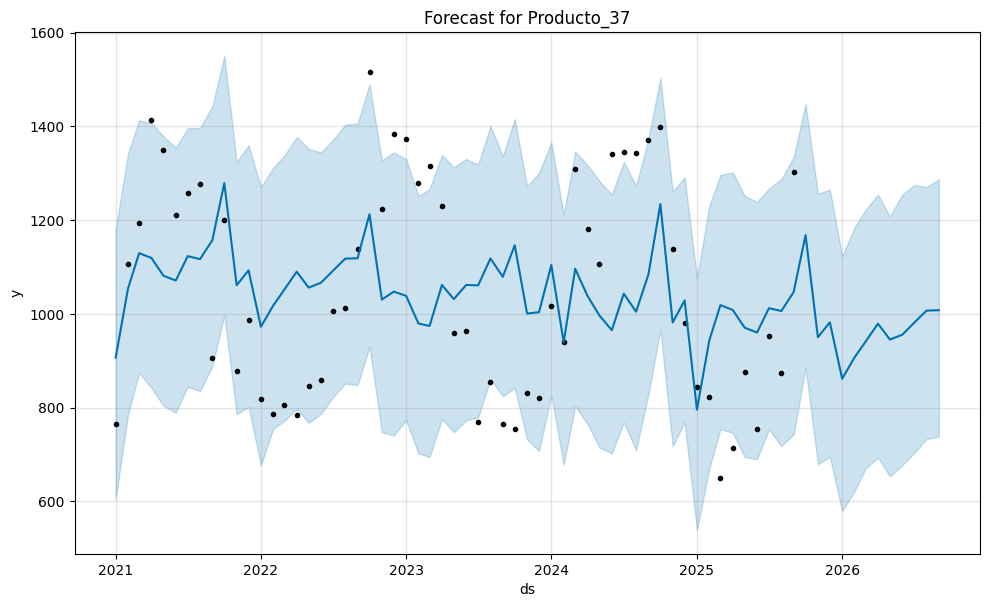

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/ni4mppsj.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/g7l9nxb5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=58143', 'data', 'file=/tmp/tmp3_yu5at0/ni4mppsj.json', 'init=/tmp/tmp3_yu5at0/g7l9nxb5.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelhxs_1xph/prophet_model-20251018151845.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:45 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:45 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


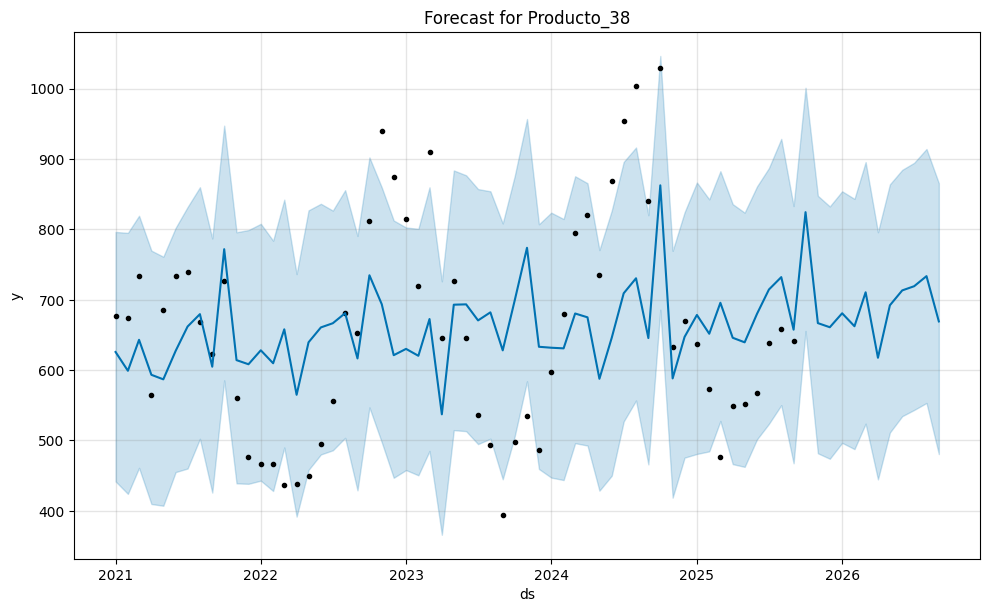

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/1umd7ylz.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/5nql9nfi.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=15139', 'data', 'file=/tmp/tmp3_yu5at0/1umd7ylz.json', 'init=/tmp/tmp3_yu5at0/5nql9nfi.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_model2uhd1dym/prophet_model-20251018151846.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:46 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:46 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


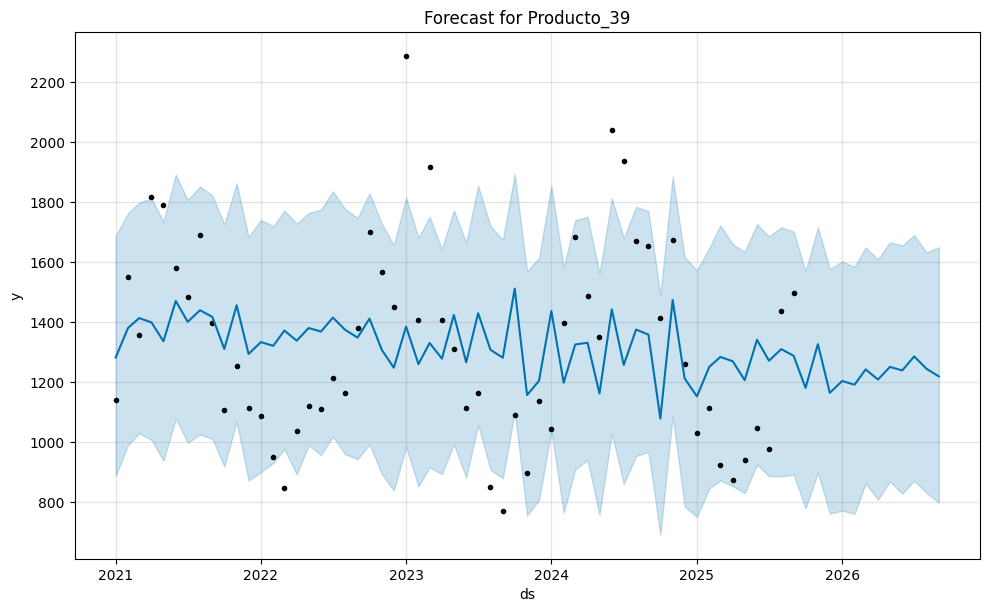

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/maynoxju.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/rs1k2zw5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=16596', 'data', 'file=/tmp/tmp3_yu5at0/maynoxju.json', 'init=/tmp/tmp3_yu5at0/rs1k2zw5.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelxoe56pr_/prophet_model-20251018151847.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:47 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:47 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


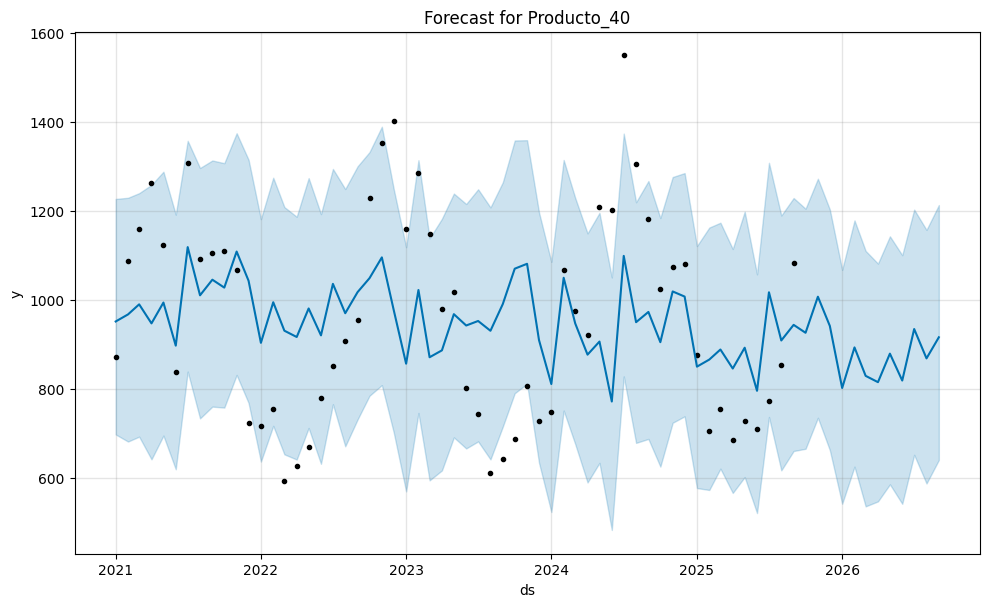

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/5fb5v4jh.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/ls6rnhxa.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=35327', 'data', 'file=/tmp/tmp3_yu5at0/5fb5v4jh.json', 'init=/tmp/tmp3_yu5at0/ls6rnhxa.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_model6m904ikq/prophet_model-20251018151848.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:48 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:48 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


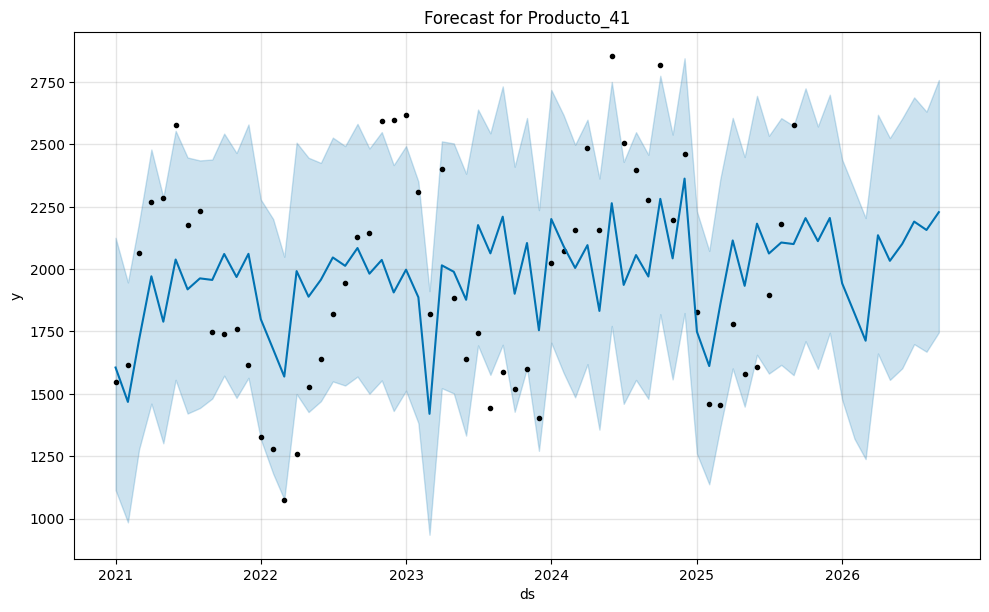

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/006xupfx.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/rmrwgcge.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=87578', 'data', 'file=/tmp/tmp3_yu5at0/006xupfx.json', 'init=/tmp/tmp3_yu5at0/rmrwgcge.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelw6mtvfkk/prophet_model-20251018151849.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:49 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:49 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


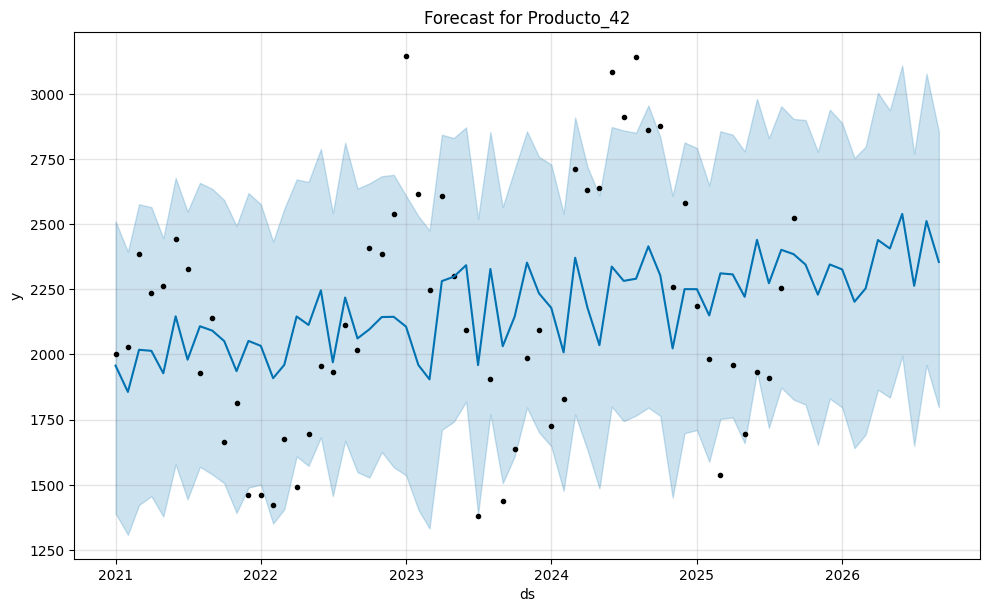

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/uvzfgfx4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/o0vl7av8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=60773', 'data', 'file=/tmp/tmp3_yu5at0/uvzfgfx4.json', 'init=/tmp/tmp3_yu5at0/o0vl7av8.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_models7be3qgm/prophet_model-20251018151850.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


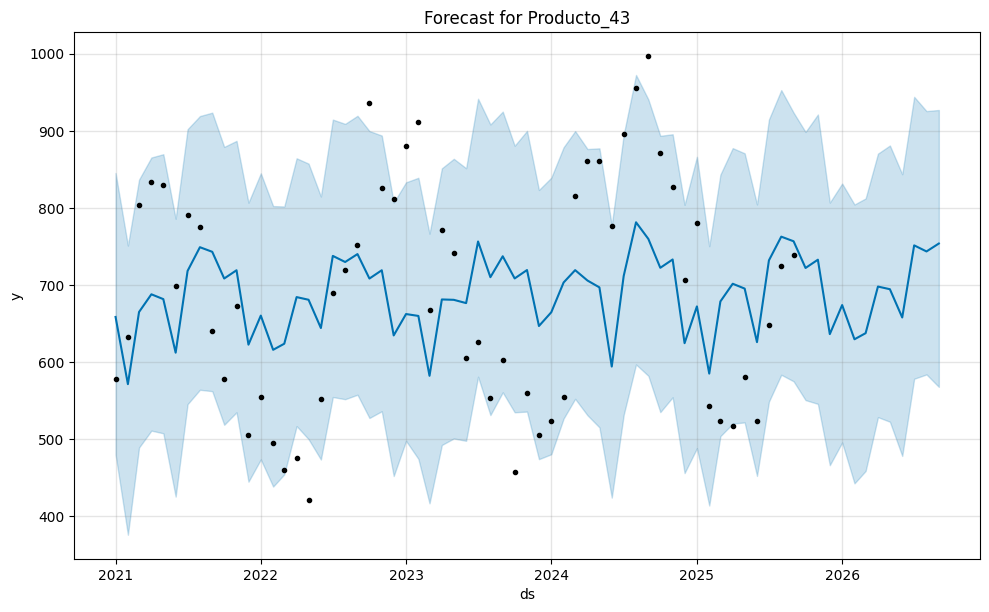

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/0hqfr9ku.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/wcfa_e_l.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=68147', 'data', 'file=/tmp/tmp3_yu5at0/0hqfr9ku.json', 'init=/tmp/tmp3_yu5at0/wcfa_e_l.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelz4uo44sg/prophet_model-20251018151851.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:51 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:51 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


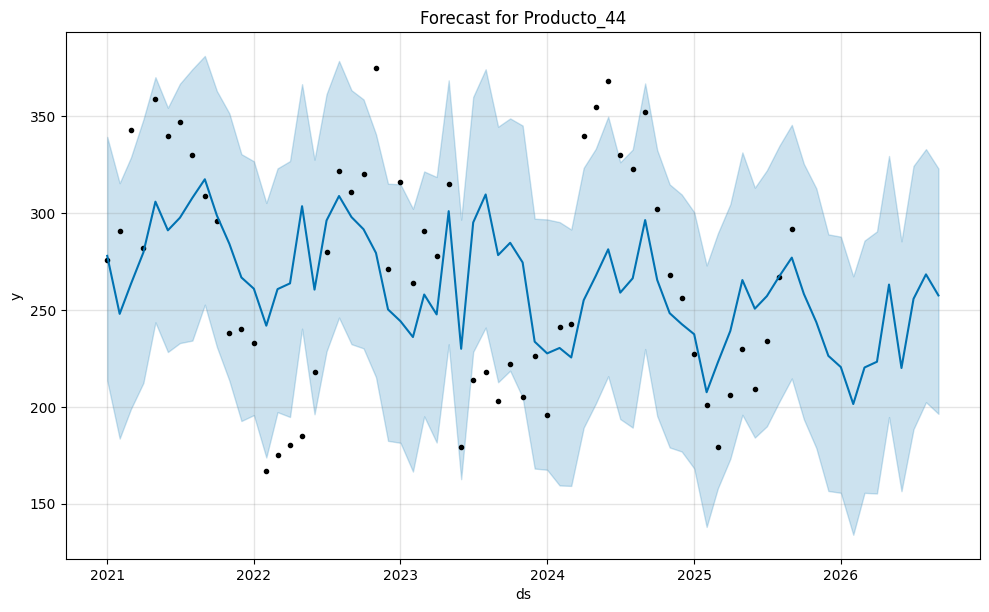

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/l1qtciw0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/1zkwy7yb.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=88757', 'data', 'file=/tmp/tmp3_yu5at0/l1qtciw0.json', 'init=/tmp/tmp3_yu5at0/1zkwy7yb.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modele7l158t2/prophet_model-20251018151852.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:52 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:52 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


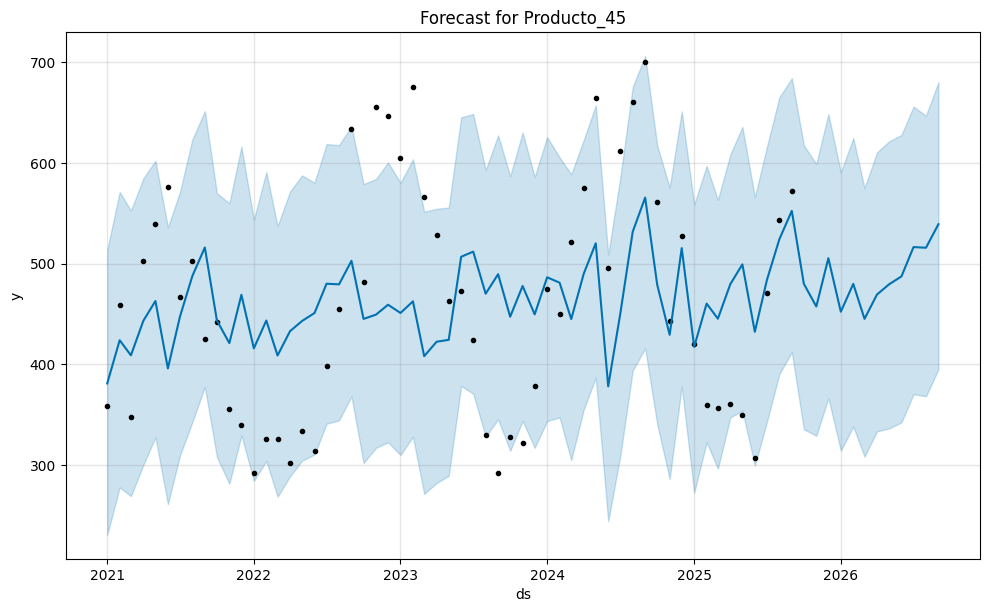

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/6s92dwsk.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/tpbe4ziv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=30963', 'data', 'file=/tmp/tmp3_yu5at0/6s92dwsk.json', 'init=/tmp/tmp3_yu5at0/tpbe4ziv.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelyksqhh0l/prophet_model-20251018151852.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:52 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:53 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


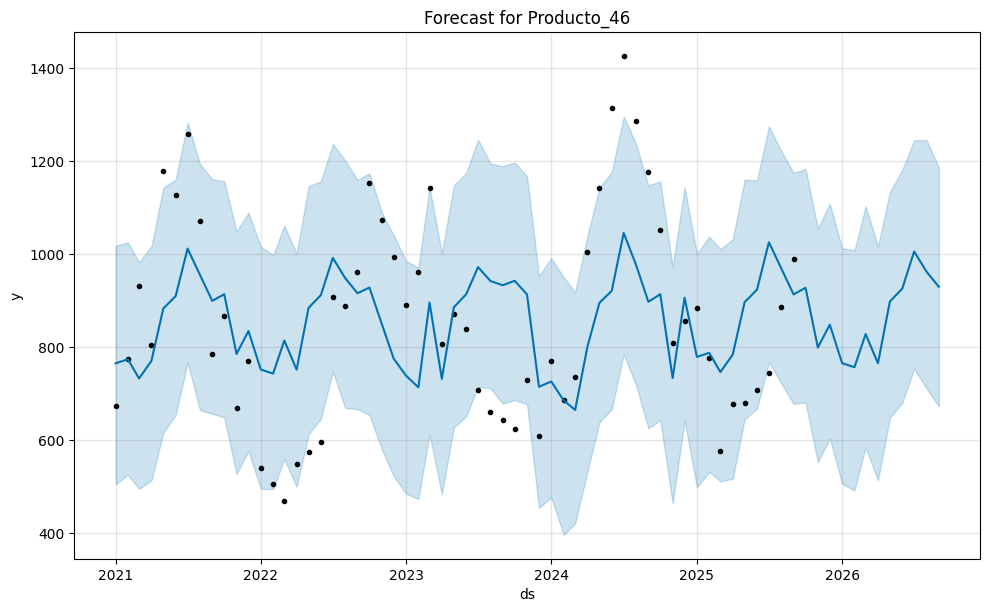

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/c8ucgnjq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/zhy3y_n5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=54247', 'data', 'file=/tmp/tmp3_yu5at0/c8ucgnjq.json', 'init=/tmp/tmp3_yu5at0/zhy3y_n5.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_model7kc7hgf2/prophet_model-20251018151853.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:53 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:54 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


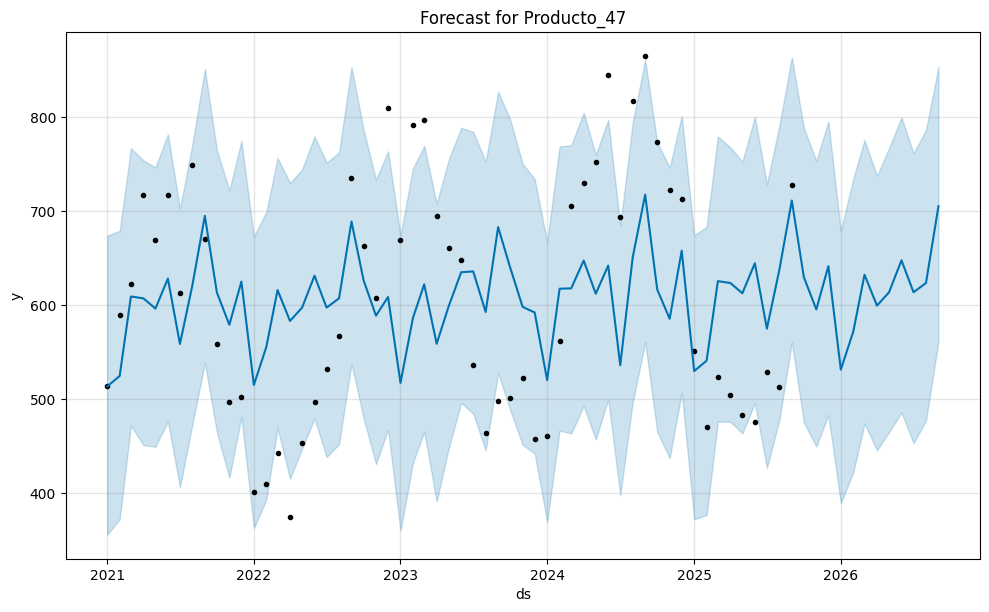

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/xb7phrrr.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/u6xs0cji.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=11737', 'data', 'file=/tmp/tmp3_yu5at0/xb7phrrr.json', 'init=/tmp/tmp3_yu5at0/u6xs0cji.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelce9hghmn/prophet_model-20251018151854.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:54 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:54 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


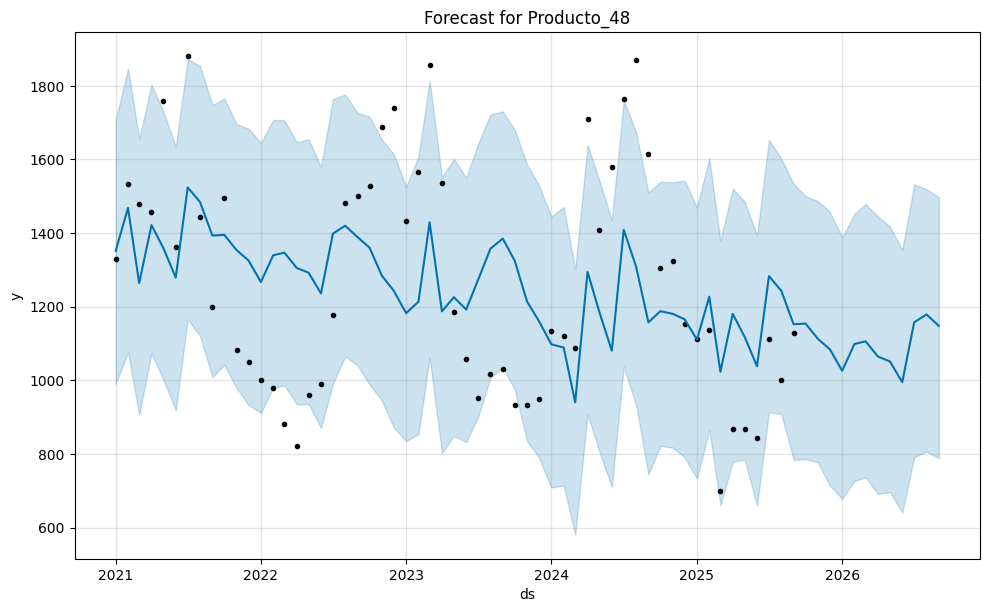

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/ws1d8tg4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/1alo13ah.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=39421', 'data', 'file=/tmp/tmp3_yu5at0/ws1d8tg4.json', 'init=/tmp/tmp3_yu5at0/1alo13ah.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modeltsiczrc3/prophet_model-20251018151855.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:55 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:55 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


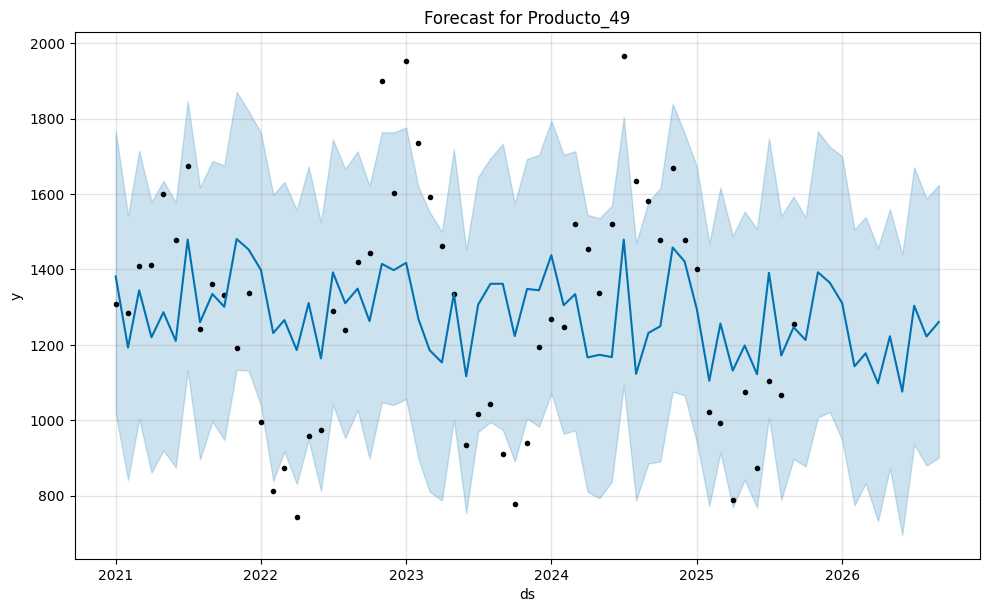

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/ea6dw5s5.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp3_yu5at0/jd5hpjh2.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=54665', 'data', 'file=/tmp/tmp3_yu5at0/ea6dw5s5.json', 'init=/tmp/tmp3_yu5at0/jd5hpjh2.json', 'output', 'file=/tmp/tmp3_yu5at0/prophet_modelti0w5pk7/prophet_model-20251018151856.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:18:56 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:18:56 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


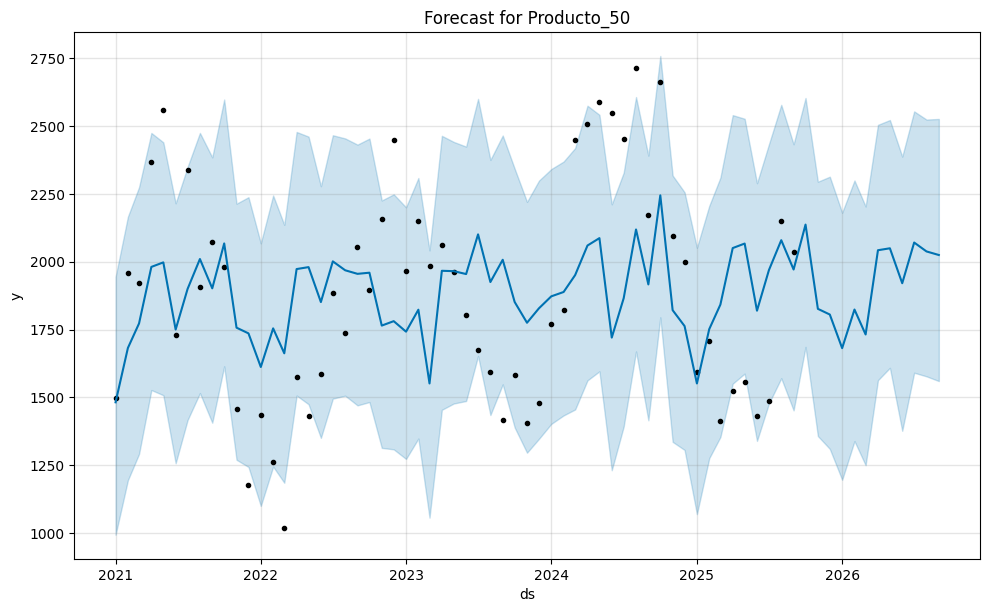

In [6]:
import matplotlib.pyplot as plt
from prophet import Prophet

for product in unique_products:
    product_df = df_melted[df_melted['Producto'] == product].copy()
    model = Prophet()
    model.fit(product_df)
    future = model.make_future_dataframe(periods=12, freq='MS')
    forecast = model.predict(future)
    fig = model.plot(forecast)
    ax = fig.gca()
    ax.set_title(f'Forecast for {product}')
    plt.show()

## Summary:

### Data Analysis Key Findings

*   The sales data from the 'Ventas\_Unidades' sheet of the provided Excel file was successfully loaded and transformed into a format suitable for the Prophet library.
*   The data was initially in a wide format and was successfully melted into a long format with columns renamed to 'ds' (date) and 'y' (sales value), along with a 'Producto' column.
*   Prophet models were individually trained for each of the unique products present in the dataset.
*   A 12-month sales forecast was generated for each product using its respective trained Prophet model.
*   The generated forecasts for each product were successfully visualized, showing the historical data, the fitted trend, and the predicted future sales with confidence intervals.

### Insights or Next Steps

*   Analyze the individual product forecasts to identify trends, seasonality, and potential outliers that might require further investigation or adjustments to the forecasting model.
*   Consolidate the individual product forecasts into a single summary table or visualization to provide an aggregated view of the total sales forecast for the next 12 months.


## Consolidar los pronósticos en un DataFrame

### Subtask:
Combinar todos los DataFrames de pronóstico individuales en un único DataFrame.

**Reasoning**:
Iterate through the `forecasts` dictionary, select the 'ds' and 'yhat' columns from each product's forecast DataFrame, rename 'yhat' to the product name, and merge these columns into a single DataFrame based on the 'ds' column.

In [7]:
# Create an empty DataFrame to store the combined forecasts
all_forecasts_df = pd.DataFrame()

for product, forecast in forecasts.items():
    # Select the date and forecast columns and rename the forecast column
    product_forecast_df = forecast[['ds', 'yhat']].rename(columns={'yhat': product})

    # Merge with the main DataFrame
    if all_forecasts_df.empty:
        all_forecasts_df = product_forecast_df
    else:
        all_forecasts_df = pd.merge(all_forecasts_df, product_forecast_df, on='ds', how='outer')

# Display the combined DataFrame
display(all_forecasts_df.head())

,ds,Producto_01,Producto_02,Producto_03,Producto_04,Producto_05,Producto_06,Producto_07,Producto_08,Producto_09,...,Producto_41,Producto_42,Producto_43,Producto_44,Producto_45,Producto_46,Producto_47,Producto_48,Producto_49,Producto_50
0,2021-01-01,1454.618691,244.734362,1634.809624,1032.251505,1085.710703,996.963397,1399.622775,1008.529680,406.053265,...,1605.475591,1956.912084,658.479499,277.929364,381.011555,765.438732,513.709432,1351.552495,1381.247982,1482.060687
1,2021-02-01,1316.342696,254.866261,2106.246389,1005.568059,1009.222860,1011.019130,1306.875754,964.496710,427.539582,...,1467.625171,1856.127162,571.364570,247.980277,423.921149,774.142595,524.818519,1468.179079,1192.735046,1682.093097
2,2021-03-01,1325.064094,277.054583,2005.376576,1051.576414,1233.083721,1066.512381,1471.909463,1012.429633,410.779150,...,1716.170954,2017.682381,664.912201,263.400106,408.930526,732.857602,609.287083,1264.037336,1344.449964,1772.359568
3,2021-04-01,1662.131211,281.442073,1832.679965,1076.652546,1050.165096,1065.662804,1567.321356,983.505276,462.847315,...,1970.971226,2013.643828,687.869349,279.659808,443.253738,770.360857,607.356031,1421.482450,1219.751878,1980.503864
4,2021-05-01,1559.158153,287.547602,2014.794538,1217.022899,1173.012939,1136.953900,1518.637490,1028.284689,422.007632,...,1789.076164,1927.599926,681.602480,305.910884,462.869759,883.380192,596.439044,1358.776150,1286.230807,1997.132244


## Finalizar la tarea

### Subtask:
Presentar los resultados de los pronósticos de manera clara.

**Reasoning**:
Display the final DataFrame containing the forecasts for all products.

In [8]:
display(all_forecasts_df)

,ds,Producto_01,Producto_02,Producto_03,Producto_04,Producto_05,Producto_06,Producto_07,Producto_08,Producto_09,...,Producto_41,Producto_42,Producto_43,Producto_44,Producto_45,Producto_46,Producto_47,Producto_48,Producto_49,Producto_50
0,2021-01-01,1454.618691,244.734362,1634.809624,1032.251505,1085.710703,996.963397,1399.622775,1008.529680,406.053265,...,1605.475591,1956.912084,658.479499,277.929364,381.011555,765.438732,513.709432,1351.552495,1381.247982,1482.060687
1,2021-02-01,1316.342696,254.866261,2106.246389,1005.568059,1009.222860,1011.019130,1306.875754,964.496710,427.539582,...,1467.625171,1856.127162,571.364570,247.980277,423.921149,774.142595,524.818519,1468.179079,1192.735046,1682.093097
2,2021-03-01,1325.064094,277.054583,2005.376576,1051.576414,1233.083721,1066.512381,1471.909463,1012.429633,410.779150,...,1716.170954,2017.682381,664.912201,263.400106,408.930526,732.857602,609.287083,1264.037336,1344.449964,1772.359568
3,2021-04-01,1662.131211,281.442073,1832.679965,1076.652546,1050.165096,1065.662804,1567.321356,983.505276,462.847315,...,1970.971226,2013.643828,687.869349,279.659808,443.253738,770.360857,607.356031,1421.482450,1219.751878,1980.503864
4,2021-05-01,1559.158153,287.547602,2014.794538,1217.022899,1173.012939,1136.953900,1518.637490,1028.284689,422.007632,...,1789.076164,1927.599926,681.602480,305.910884,462.869759,883.380192,596.439044,1358.776150,1286.230807,1997.132244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,2026-05-01,1758.999694,223.193535,2455.148944,1128.373801,1237.584979,1171.719810,1288.038827,1184.088463,380.671873,...,2033.007994,2406.257365,694.459839,263.100952,479.381394,898.548017,613.749326,1051.223253,1222.498312,2049.039852
65,2026-06-01,1737.898613,241.622580,2404.489897,1161.183014,1221.671131,1244.896462,1425.727160,1149.732299,405.528642,...,2100.833995,2538.956403,657.801088,220.025016,487.288223,926.008841,647.720908,994.937842,1075.646813,1920.409441
66,2026-07-01,1653.149625,264.596745,2443.978432,1141.450283,1215.833257,1169.068899,1422.343982,1165.984637,418.861372,...,2190.210055,2263.021178,751.344795,255.743988,516.382161,1006.190928,613.824958,1157.479231,1303.752009,2070.227125
67,2026-08-01,1818.167845,261.106786,2540.893006,1252.474548,1209.429204,1255.193643,1435.639266,1164.575058,428.315585,...,2156.653891,2511.464527,743.441335,268.372437,515.735049,962.711448,623.627966,1178.888268,1221.937455,2037.455068
